
# Introduction

In this project, we will see how to train a logistic regression model. This is intended as an introduction to logistic regression. However, we will not go through the mathematical intuition of the model. 

We will be working with the Breast Cancer dataset, which contains some very detailed measurements of cells. Along with each observation of measurements, we have the **diagnosis** of the cell: malignant(m) or not (b). Our goal is to train a model that will be able to predict whether or not a given cell is malignant given only its measurements.

In [51]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# import warnings
# warnings.filterwarnings('ignore')

# 1. Problem formulation:
Create a ML model that would make prediction on whether a patient has breast cancer or not. 

## 2. Data collection
Let's start exploring the dataset and get a feel of what it represents. We can, for example, see that all the variables in our dataset –except the ID and the diagnosis– are already of type float64, which means that they are numerical. This is great for our intitial intuition of using a logistic regression model. This is because the logistic regression model takes numerical values as input and outputs a binary classification value (yes/no value).

In [52]:
df = pd.read_csv("breast_cancer.csv")
print(df.head(5))

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [53]:
print(df.tail(5))

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
564  926424         M        21.56         22.39          142.00     1479.0   
565  926682         M        20.13         28.25          131.20     1261.0   
566  926954         M        16.60         28.08          108.30      858.1   
567  927241         M        20.60         29.33          140.10     1265.0   
568   92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
564          0.11100           0.11590         0.24390              0.13890   
565          0.09780           0.10340         0.14400              0.09791   
566          0.08455           0.10230         0.09251              0.05302   
567          0.11780           0.27700         0.35140              0.15200   
568          0.05263           0.04362         0.00000              0.00000   

     ...  texture_worst  perimeter_worst  area_wor

##### observation: 
There is one extra column : 'Unnamed: 32'. We will remove this later

## 3. Data Labeling:
This is already done

## 4. EDA

In [54]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [55]:
print(df.shape)

(569, 33)


### Observations from dataset
- columns ending with _worst typically represent the worst-case values or maximum values for certain measurements (e.g., tumor characteristics like radius, texture, smoothness, etc.). These columns are calculated to provide the worst observed performance for each feature across all samples.
- columns ending with _se: Standard error, showing variability.

In [56]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [57]:
# Lets look at above data at a different way: i.e. transpose above. Use the method that you find convenient
print(df.describe().T)

                         count          mean           std          min  \
id                       569.0  3.037183e+07  1.250206e+08  8670.000000   
radius_mean              569.0  1.412729e+01  3.524049e+00     6.981000   
texture_mean             569.0  1.928965e+01  4.301036e+00     9.710000   
perimeter_mean           569.0  9.196903e+01  2.429898e+01    43.790000   
area_mean                569.0  6.548891e+02  3.519141e+02   143.500000   
smoothness_mean          569.0  9.636028e-02  1.406413e-02     0.052630   
compactness_mean         569.0  1.043410e-01  5.281276e-02     0.019380   
concavity_mean           569.0  8.879932e-02  7.971981e-02     0.000000   
concave points_mean      569.0  4.891915e-02  3.880284e-02     0.000000   
symmetry_mean            569.0  1.811619e-01  2.741428e-02     0.106000   
fractal_dimension_mean   569.0  6.279761e-02  7.060363e-03     0.049960   
radius_se                569.0  4.051721e-01  2.773127e-01     0.111500   
texture_se               

In [58]:
# Lets look at target/response variable: Show me the unique values in column diagonsis

print(df['diagnosis'].unique())

['M' 'B']


diagnosis
B    357
M    212
Name: count, dtype: int64


C:\Users\hi\AppData\Local\Temp\ipykernel_22464\828839367.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['diagnosis'], palette='husl')


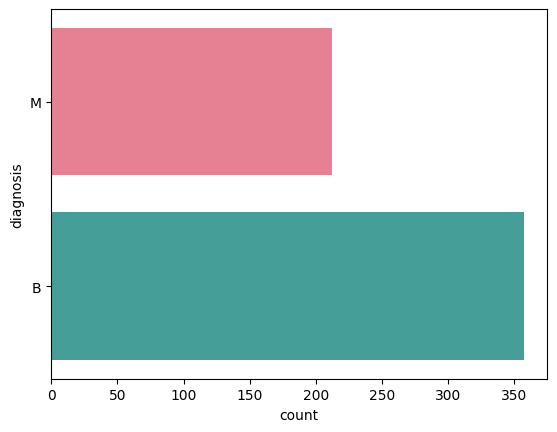

In [59]:
#  Now show me the count of these unique values

print(df['diagnosis'].value_counts())
sns.countplot(df['diagnosis'], palette='husl')
plt.show()

In [60]:
# Get value counts as percentages: TODO
# df['percentage_counts'] = df['diagnosis'].value_counts(normalize=True) * 100

percentage_counts = df['diagnosis'].value_counts(normalize=True) * 100
print(percentage_counts)

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


## 5. Data Preprocessing and Feature Engineering
Clean the data

By using a heatmap, we can easily visualize the presence of NAs in the dataset and address them accordingly. In this example, the dataset come with an entire column of NAs. We will drop it, along with the ID column (which is useless for our purposes) and continue with our analysis. 

We will also be converting our target variable into 1s and 0s in order to train the model.

Other than that, the dataset seems to be rather clean, so we will not need any further cleaning.

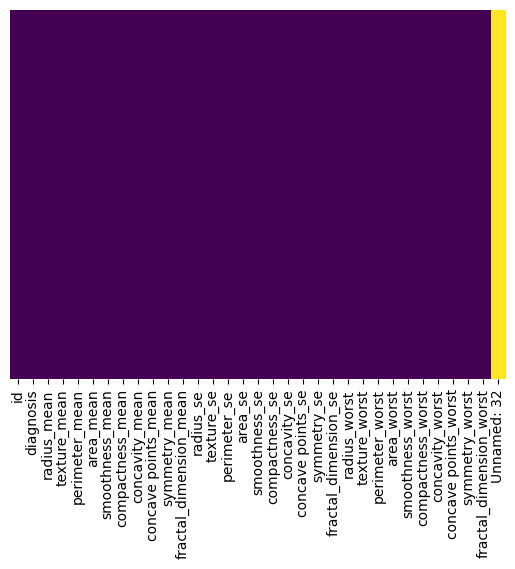

In [61]:
# lets identify NAs using visual tool in heatmap
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

#### We see that entire column Unnamed: 32 is empty


In [62]:
# drop id and empty column
df.drop(['Unnamed: 32', "id"], axis=1, inplace=True)

In [63]:
# check missing values
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [64]:
# turn target variable into 1s and 0s
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})

In [65]:
print(df.head(5))

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          

### Distribution curve, skewness, kurtosis

array([[<Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>],
       [<Axes: title={'center': 'radius_se'}>,
        <Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>],
       [<Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>,
        <Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 'symmetry_se'}>,
        <Axes: title={'ce

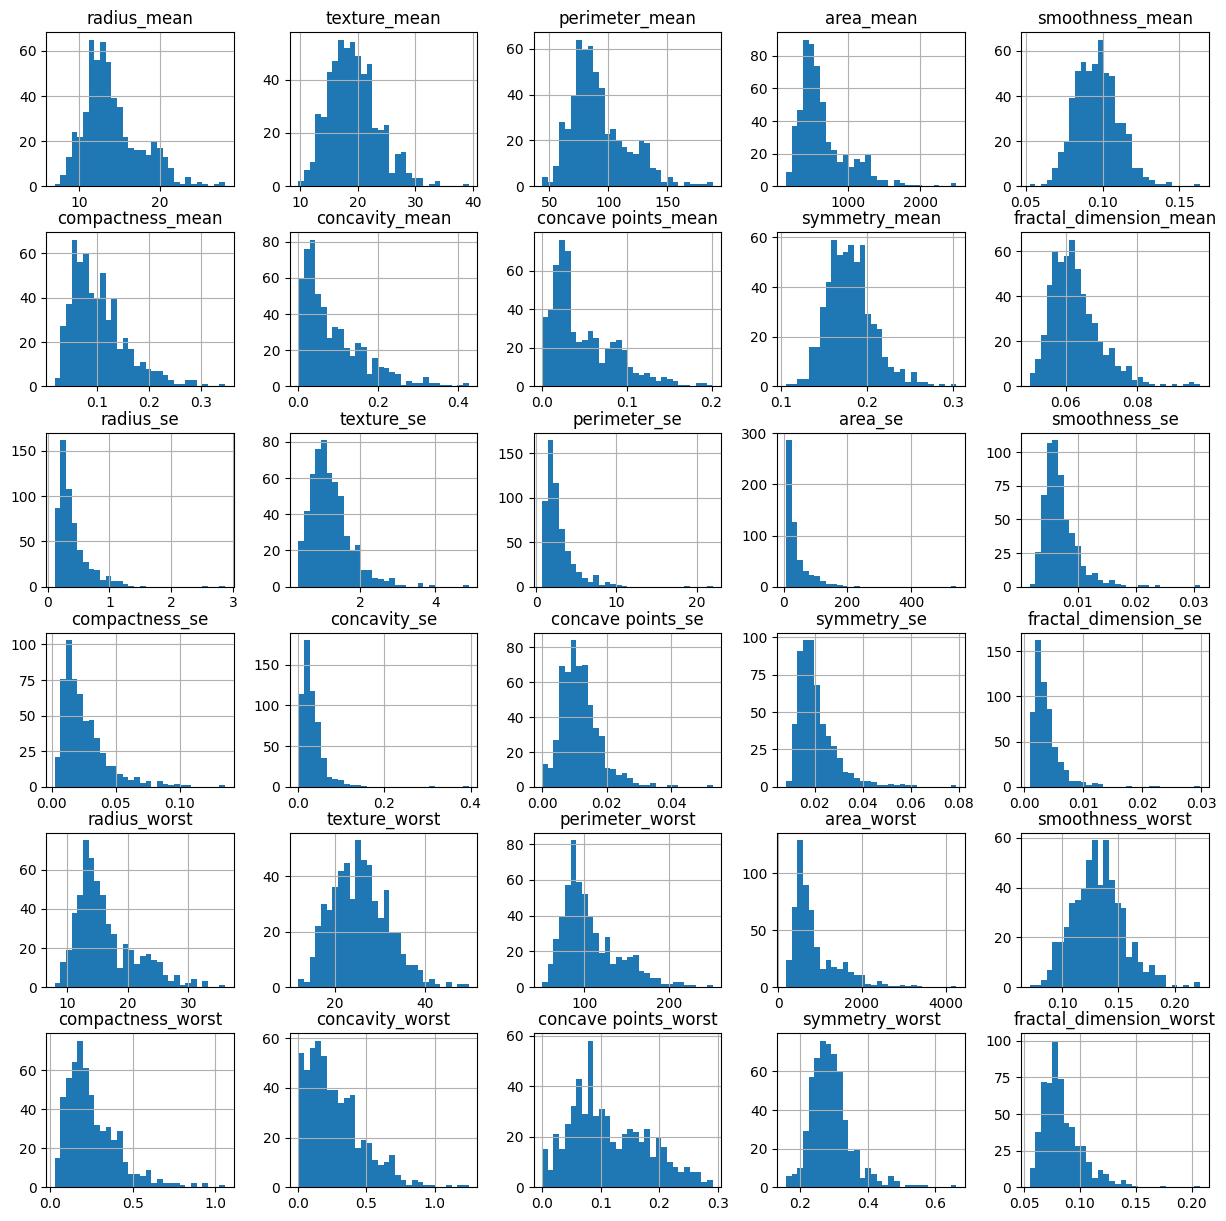

In [66]:
# I want to see how the data is distributed. So I use histogram
# THIS TOOK 30 sec
cols_to_exclude = ['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

df_num.hist(figsize=(15,15), bins=30)

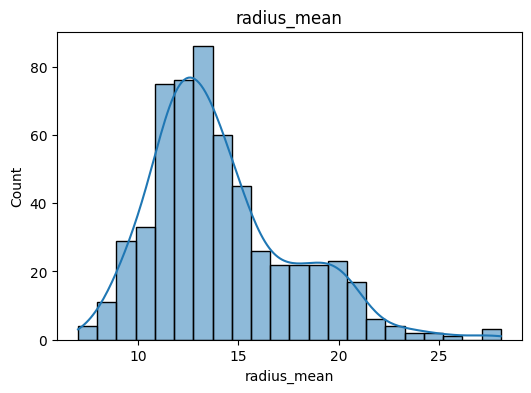

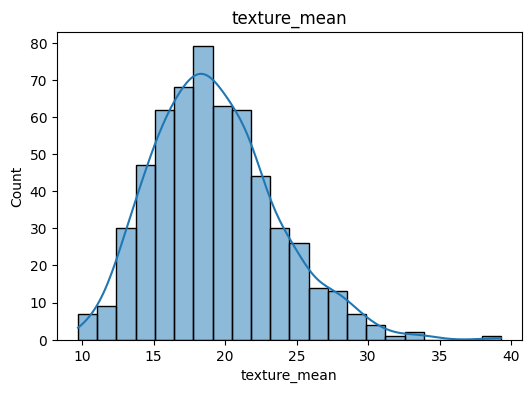

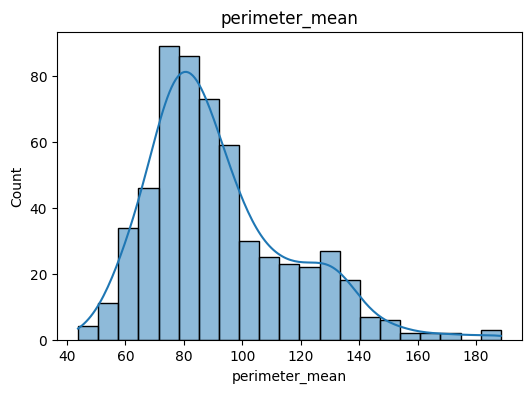

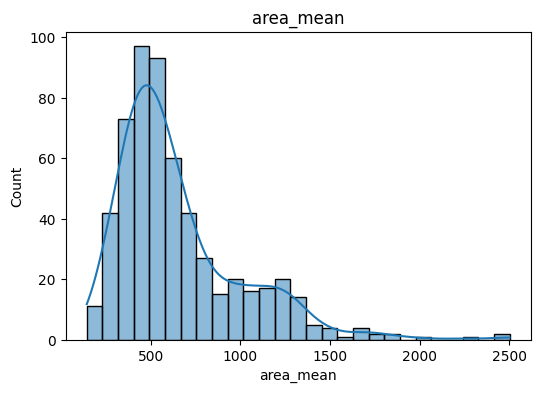

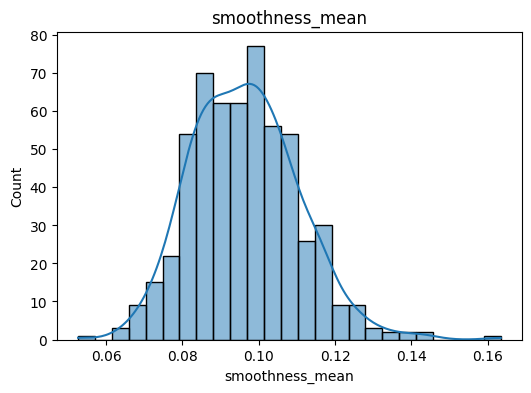

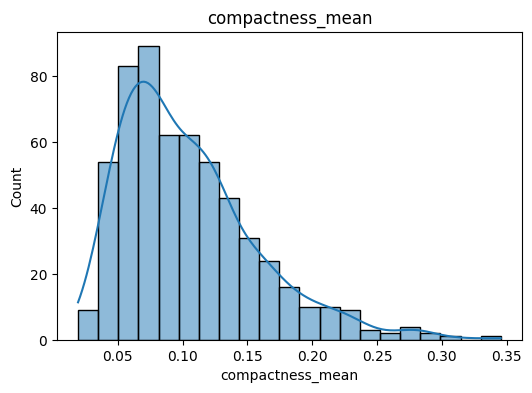

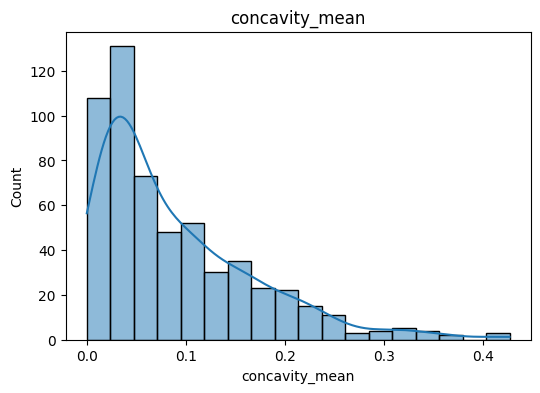

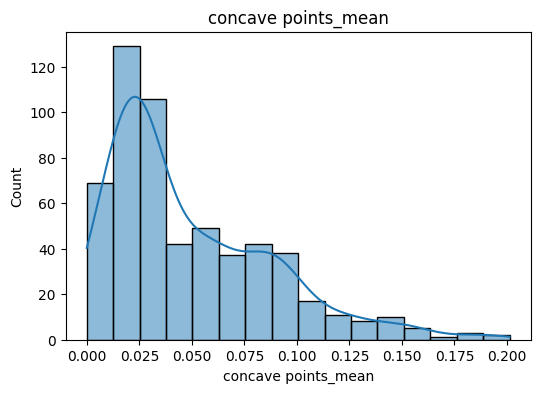

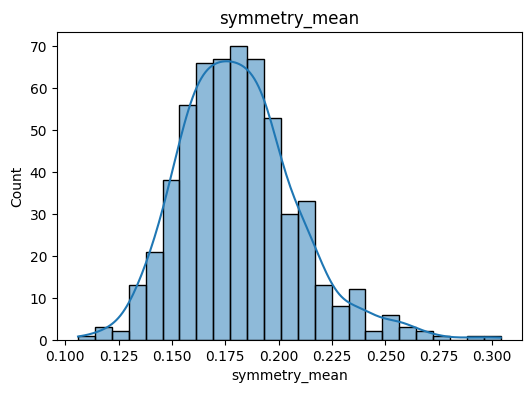

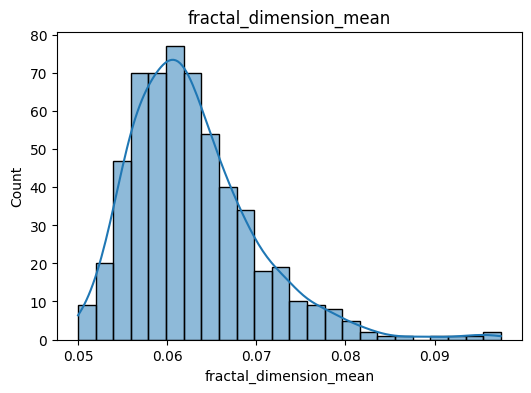

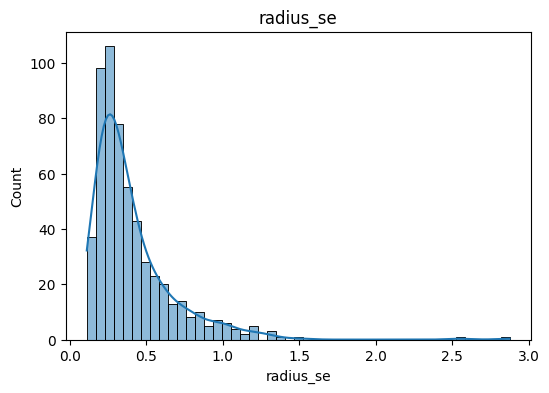

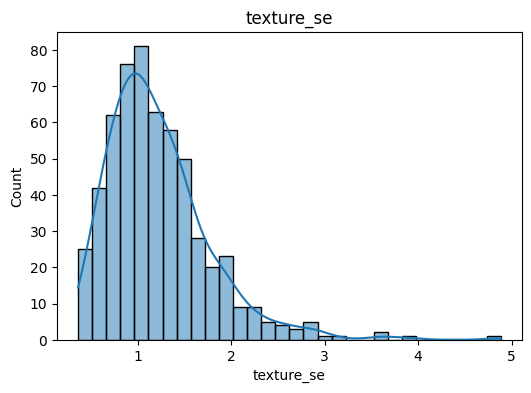

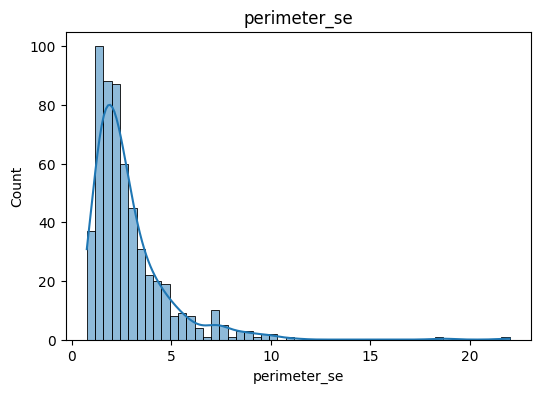

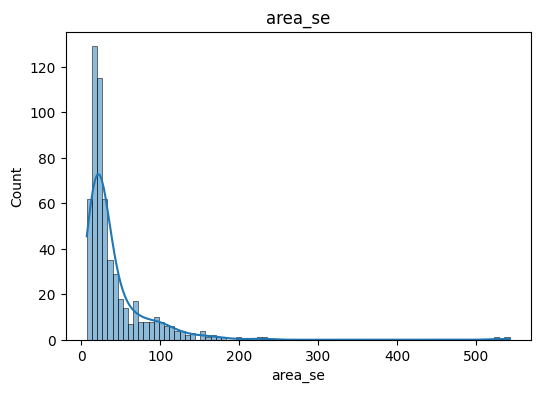

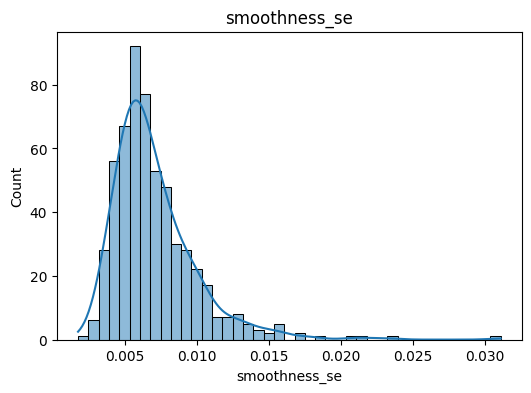

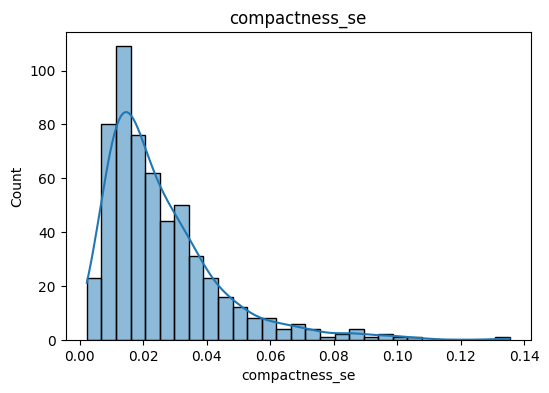

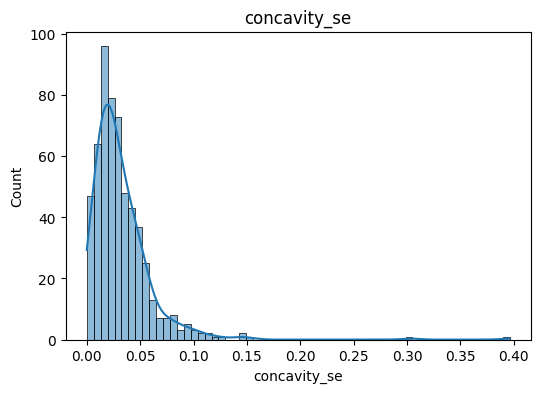

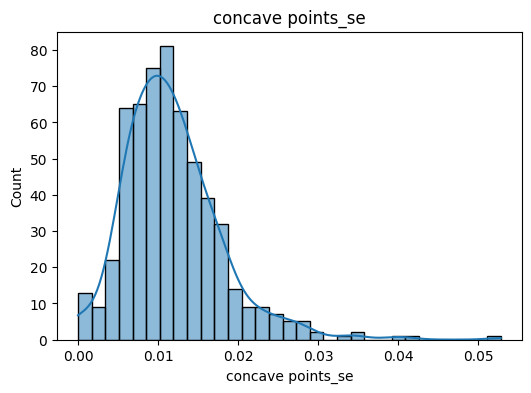

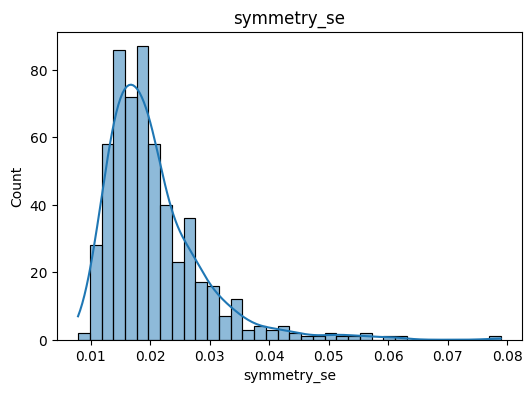

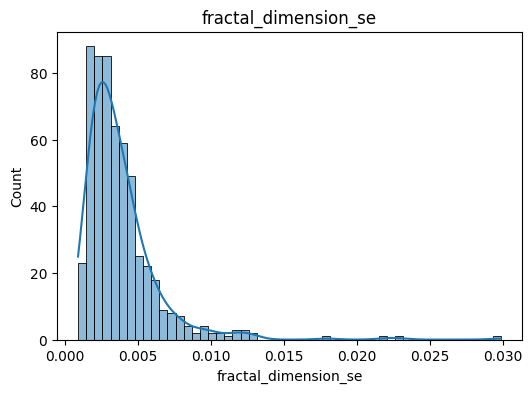

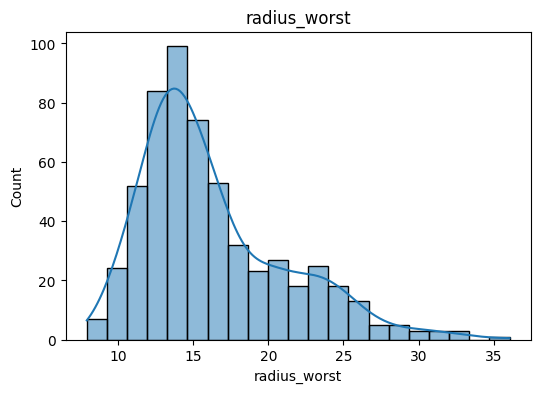

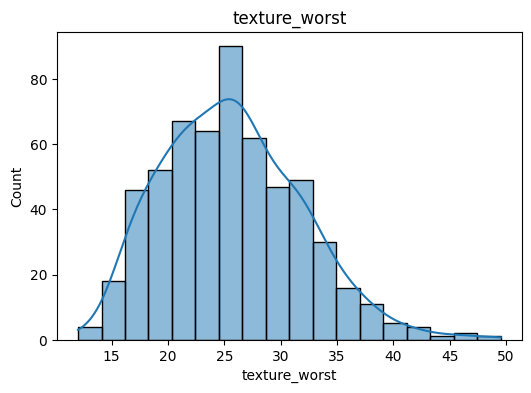

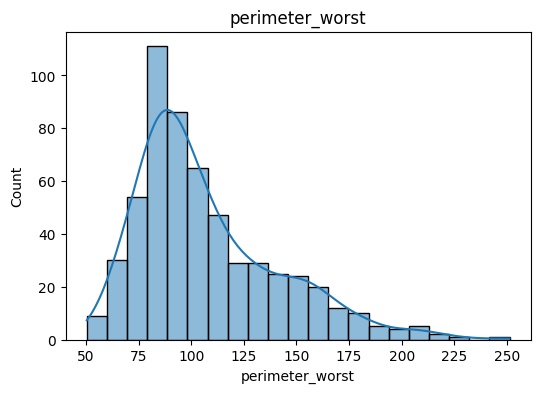

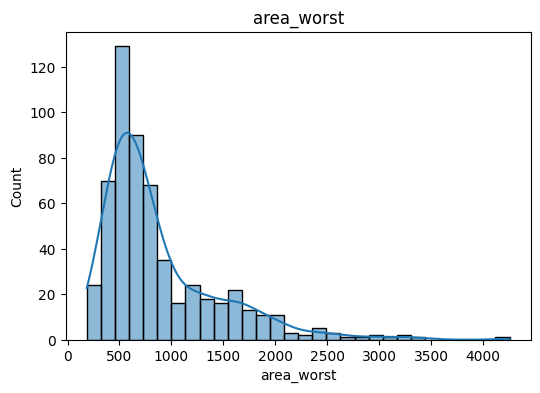

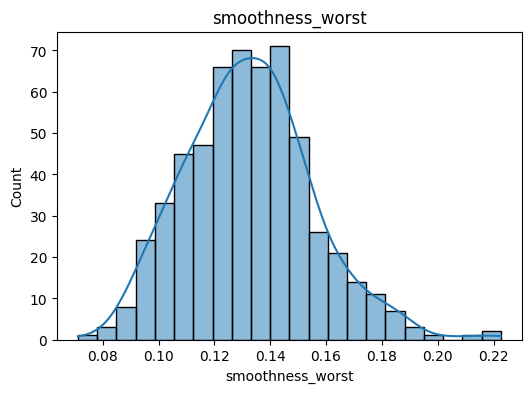

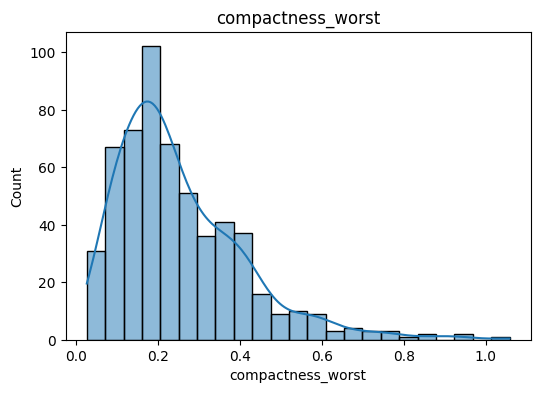

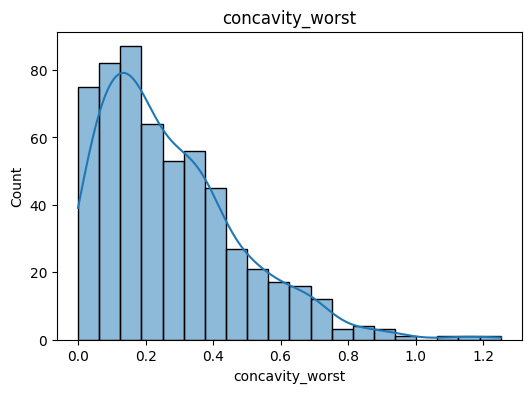

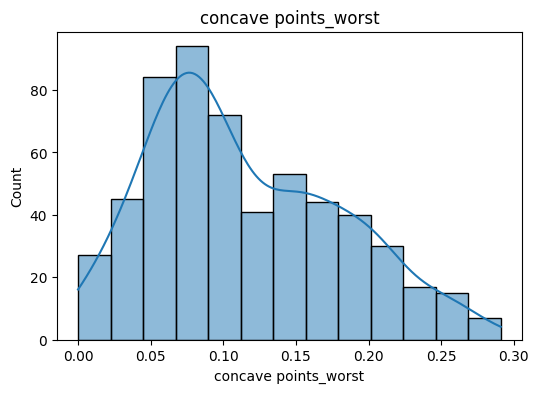

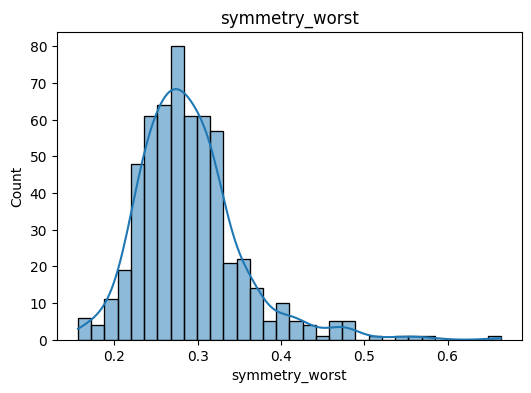

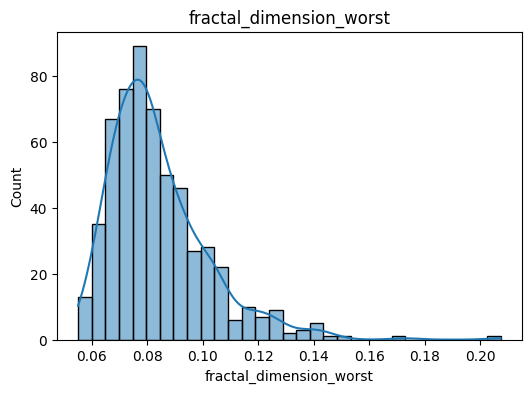

In [67]:
# Now I want to see the KDE plot too...

cols_to_exclude = ['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

for col in df_num.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


In [68]:
# Lets see the skewness
cols_to_exclude =['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

print("Skewness of columns:\n", df_num.skew())

# Rule of thumb:
# ≈ 0 → symmetric distribution: e.g. smoothness_mean, texture_worst, smoothness_worst
# > 0 → positively skewed (long right tail). e.g. radius_se, area_se, concavity_se
# < 0 → negatively skewed (long left tail)

Skewness of columns:
 radius_mean                0.942380
texture_mean               0.650450
perimeter_mean             0.990650
area_mean                  1.645732
smoothness_mean            0.456324
compactness_mean           1.190123
concavity_mean             1.401180
concave points_mean        1.171180
symmetry_mean              0.725609
fractal_dimension_mean     1.304489
radius_se                  3.088612
texture_se                 1.646444
perimeter_se               3.443615
area_se                    5.447186
smoothness_se              2.314450
compactness_se             1.902221
concavity_se               5.110463
concave points_se          1.444678
symmetry_se                2.195133
fractal_dimension_se       3.923969
radius_worst               1.103115
texture_worst              0.498321
perimeter_worst            1.128164
area_worst                 1.859373
smoothness_worst           0.415426
compactness_worst          1.473555
concavity_worst            1.150237
concav

In [69]:
# Lets look at Kurtosis (peakedness) 
cols_to_exclude = ['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

print("Kurtosis of columns:\n", df_num.kurt())

# How to read Kurtosis (peakedness)
# ≈ 3 → normal distribution: e.g. fractal_dimension_mean, 
# > 3 → heavy tails (leptokurtic). e.g.: radius_se, perimeter_se, area_se
# < 3 → light tails (platykurtic). e.g.: concave points_worst

Kurtosis of columns:
 radius_mean                 0.845522
texture_mean                0.758319
perimeter_mean              0.972214
area_mean                   3.652303
smoothness_mean             0.855975
compactness_mean            1.650130
concavity_mean              1.998638
concave points_mean         1.066556
symmetry_mean               1.287933
fractal_dimension_mean      3.005892
radius_se                  17.686726
texture_se                  5.349169
perimeter_se               21.401905
area_se                    49.209077
smoothness_se              10.469840
compactness_se              5.106252
concavity_se               48.861395
concave points_se           5.126302
symmetry_se                 7.896130
fractal_dimension_se       26.280847
radius_worst                0.944090
texture_worst               0.224302
perimeter_worst             1.070150
area_worst                  4.396395
smoothness_worst            0.517825
compactness_worst           3.039288
concavity_worst 

In [70]:
### Outliers

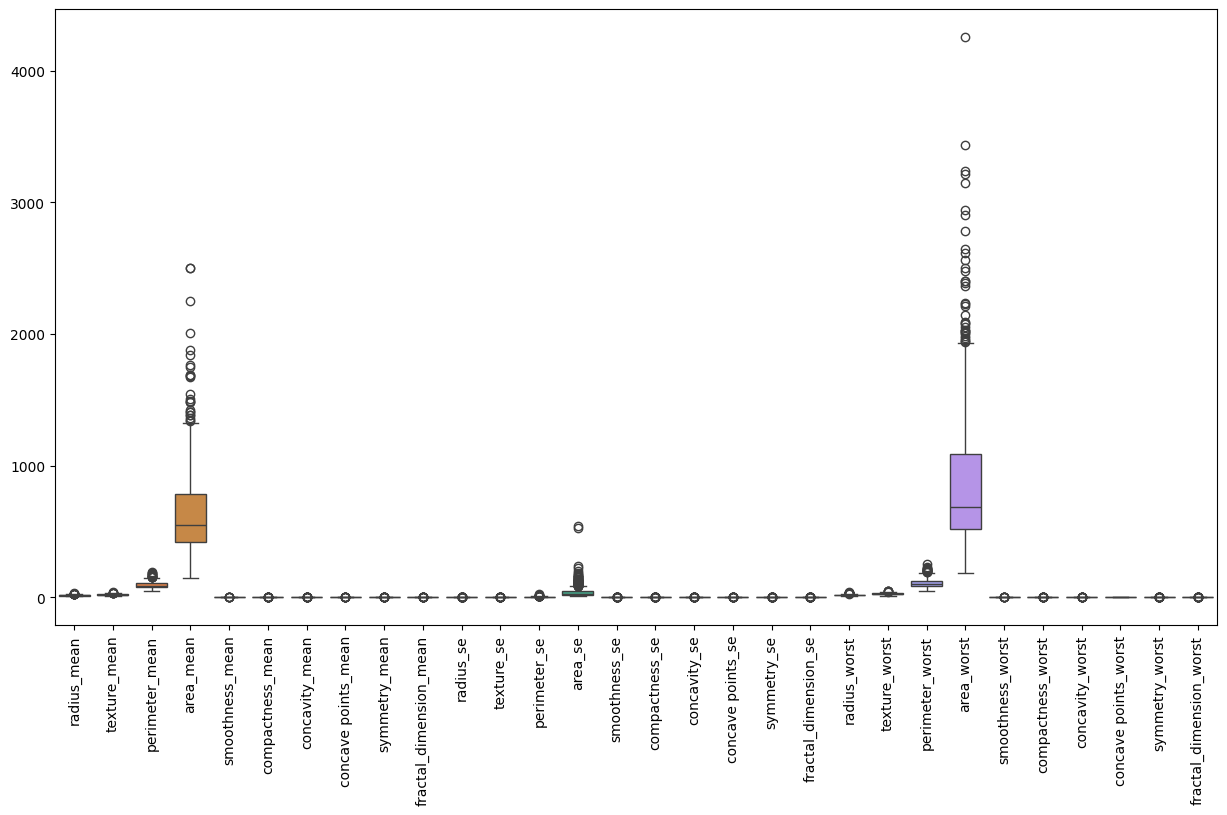

In [71]:
# step1
cols_to_exclude = ['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

plt.figure(figsize=(15,8))
sns.boxplot(data=df_num)
plt.xticks(rotation=90)
plt.show()

# observation:
# We see there are outliers, but because of different scales in the column data, 
# the values are not very easy to spot. So let plot them seperately using for loop

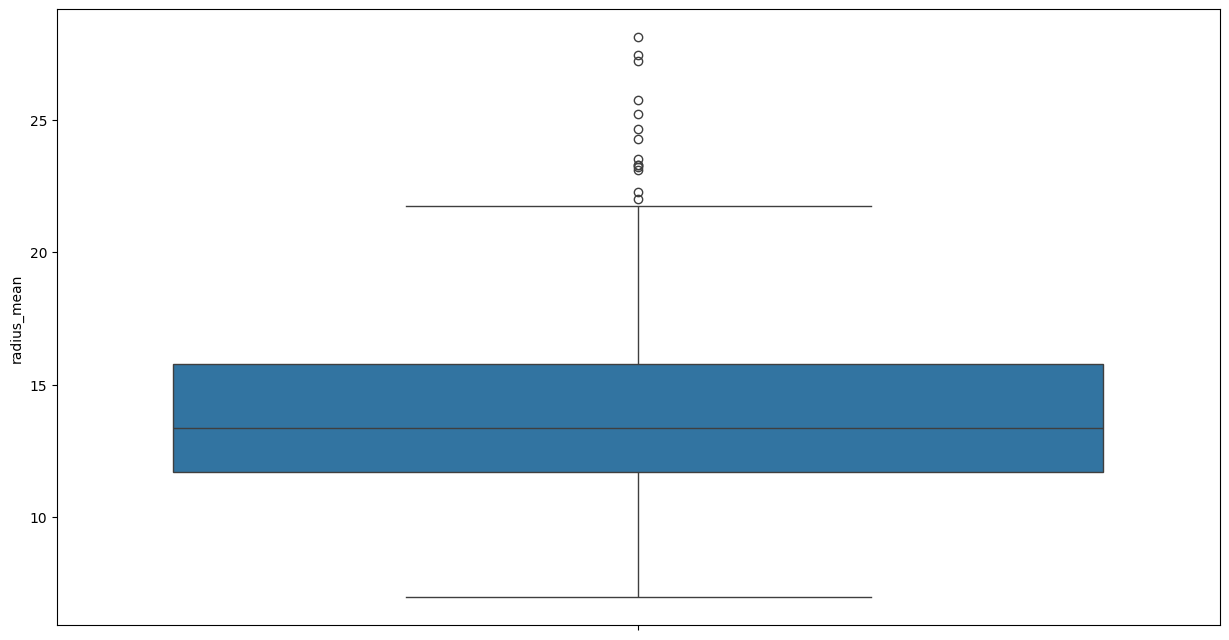

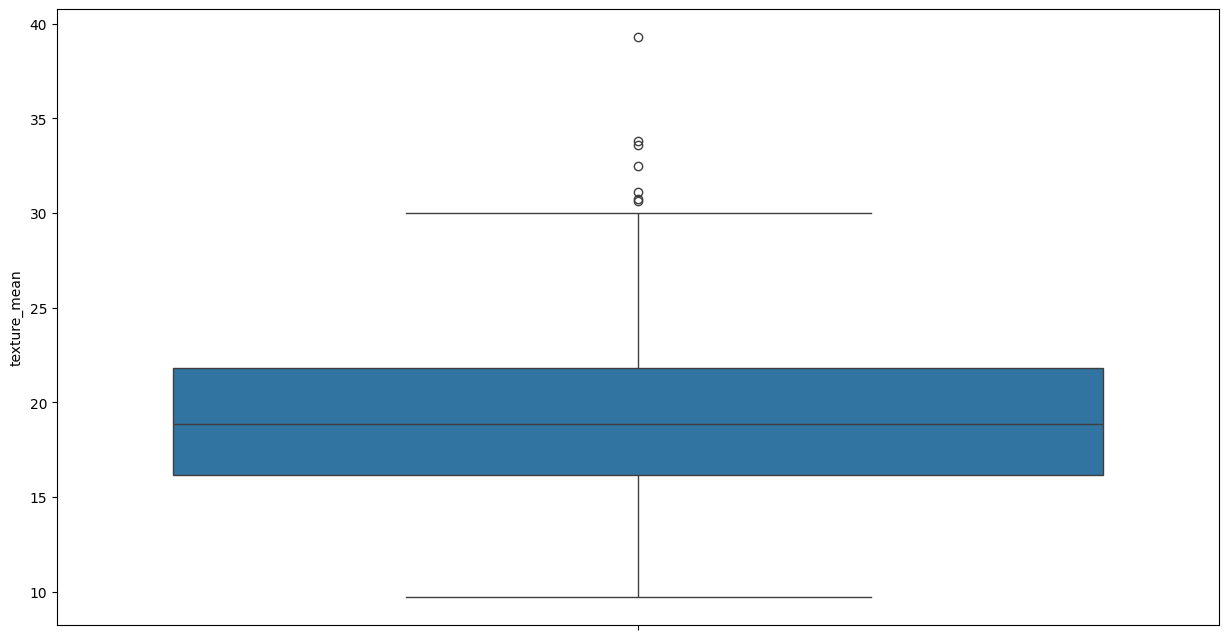

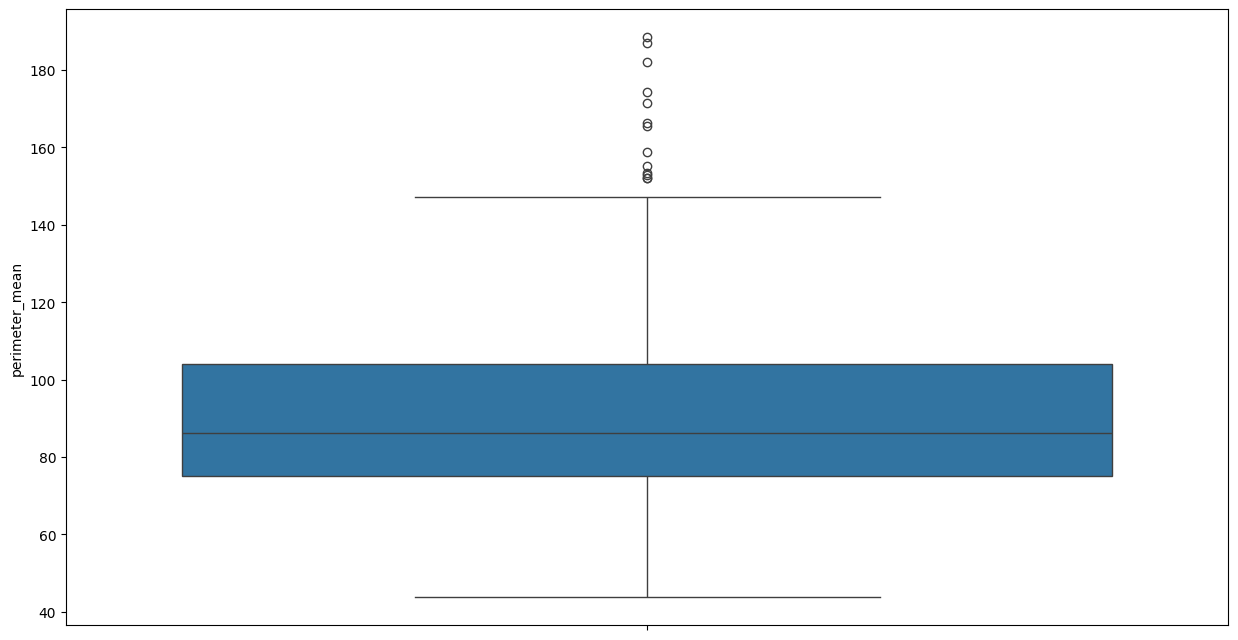

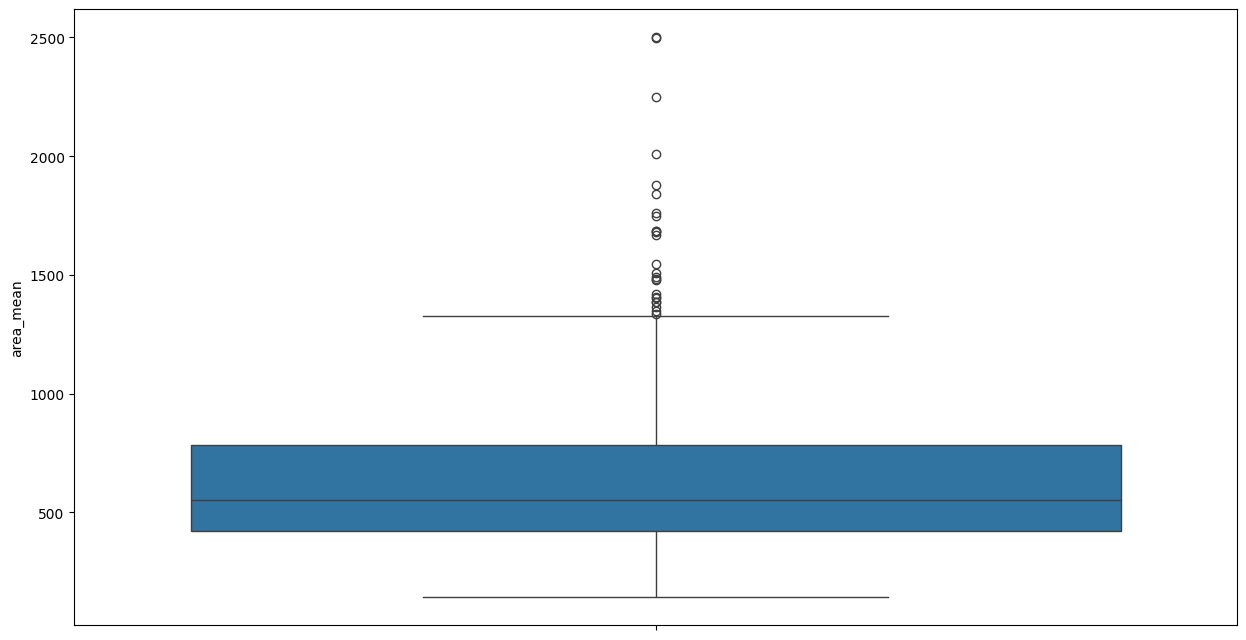

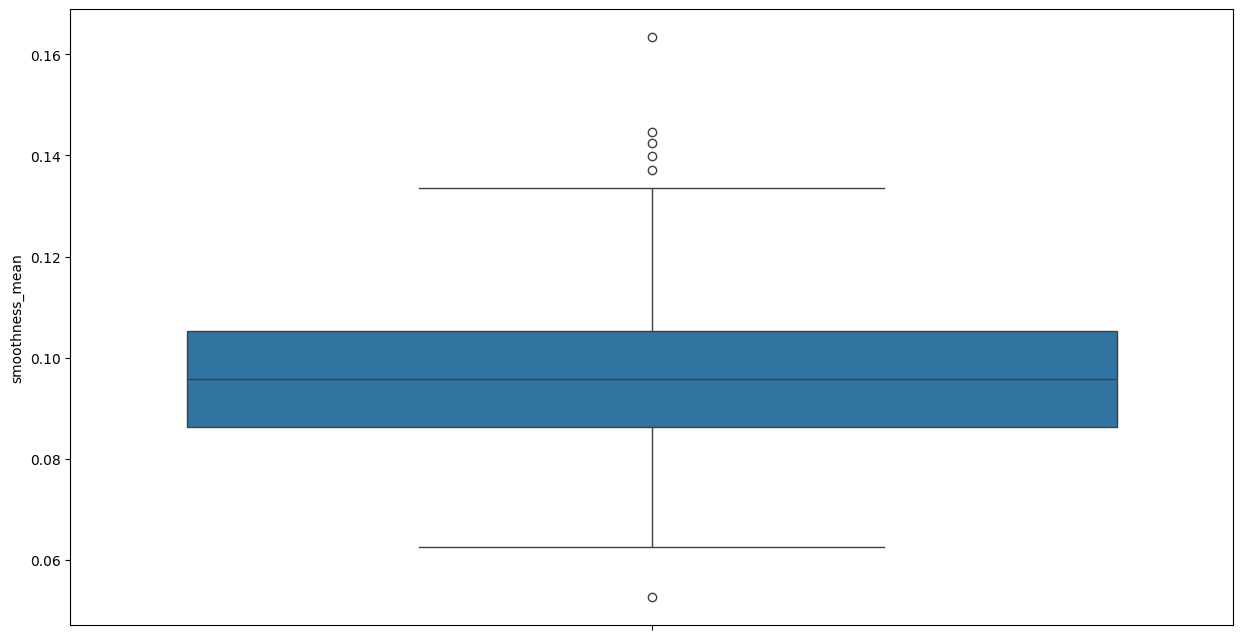

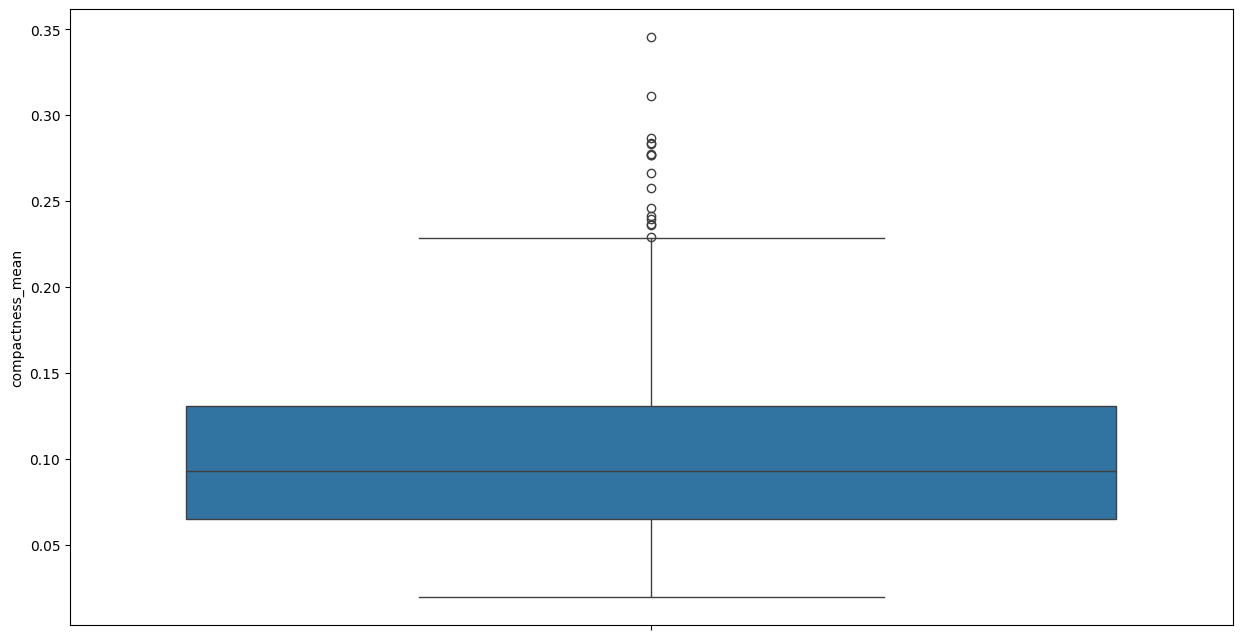

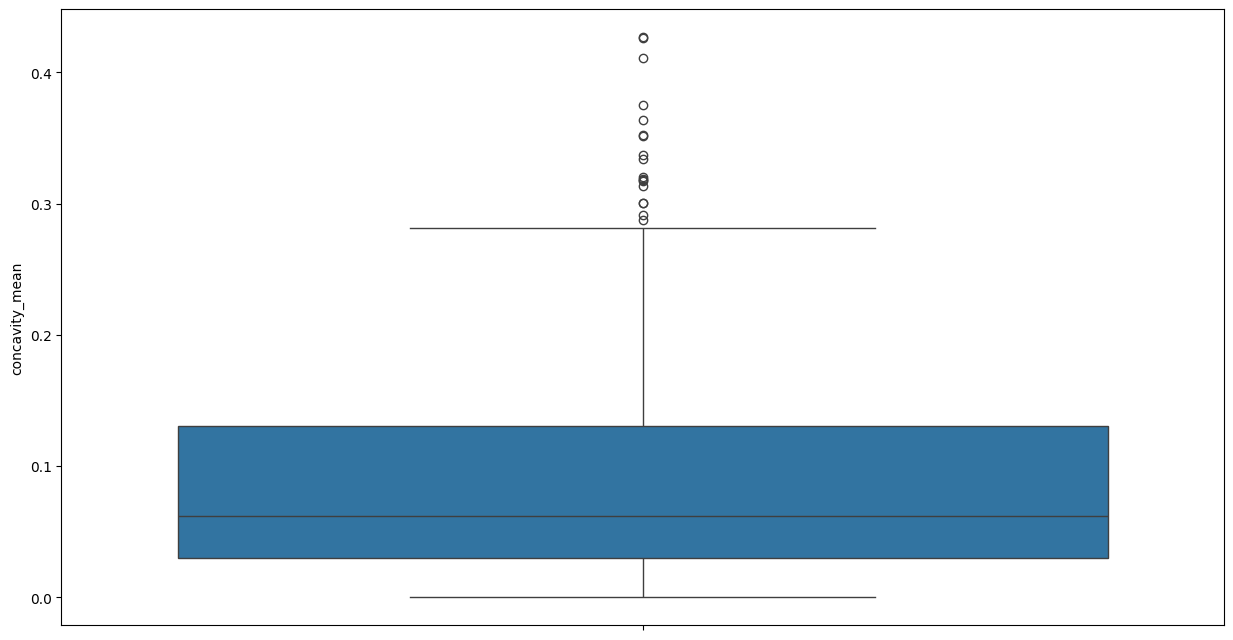

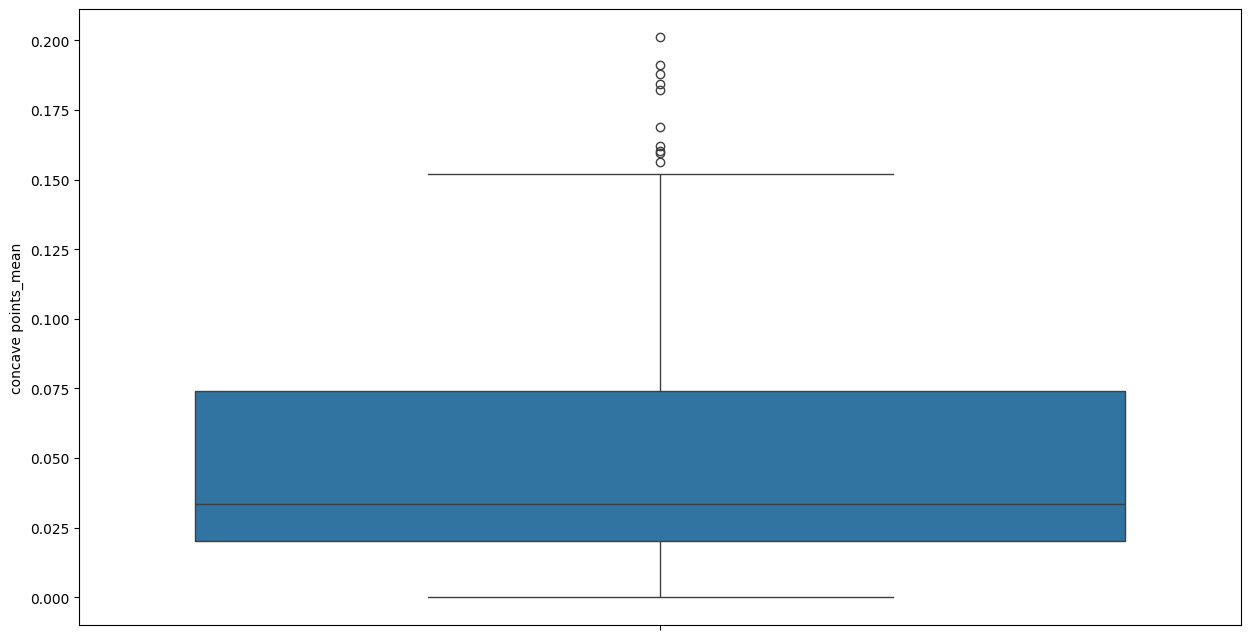

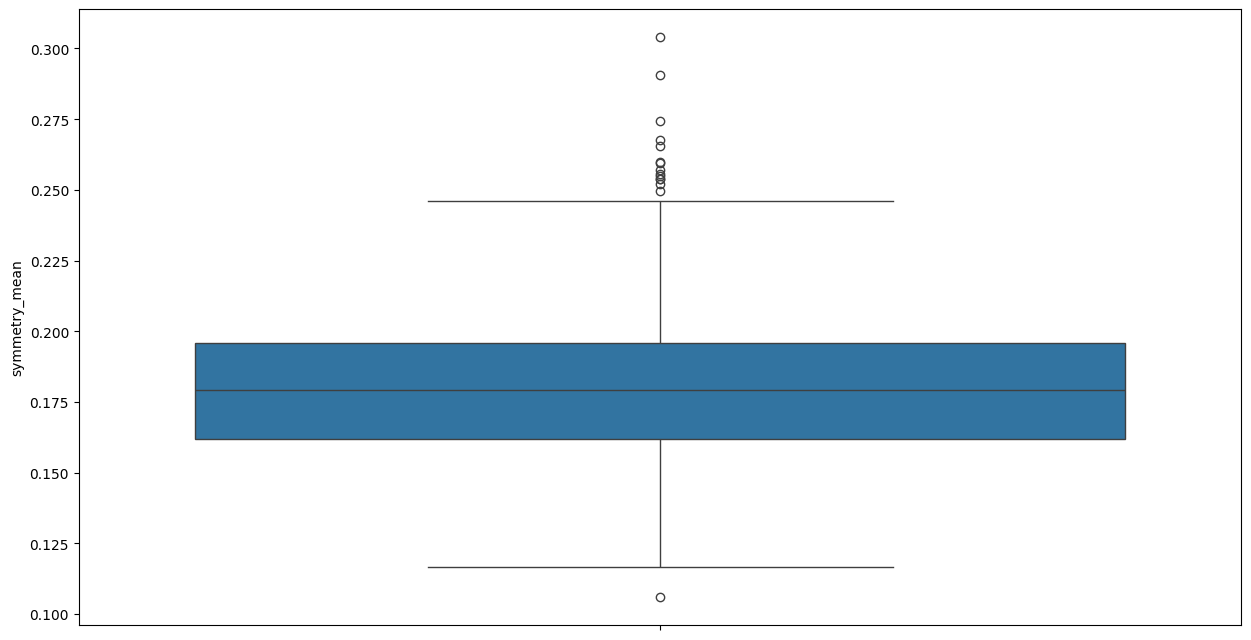

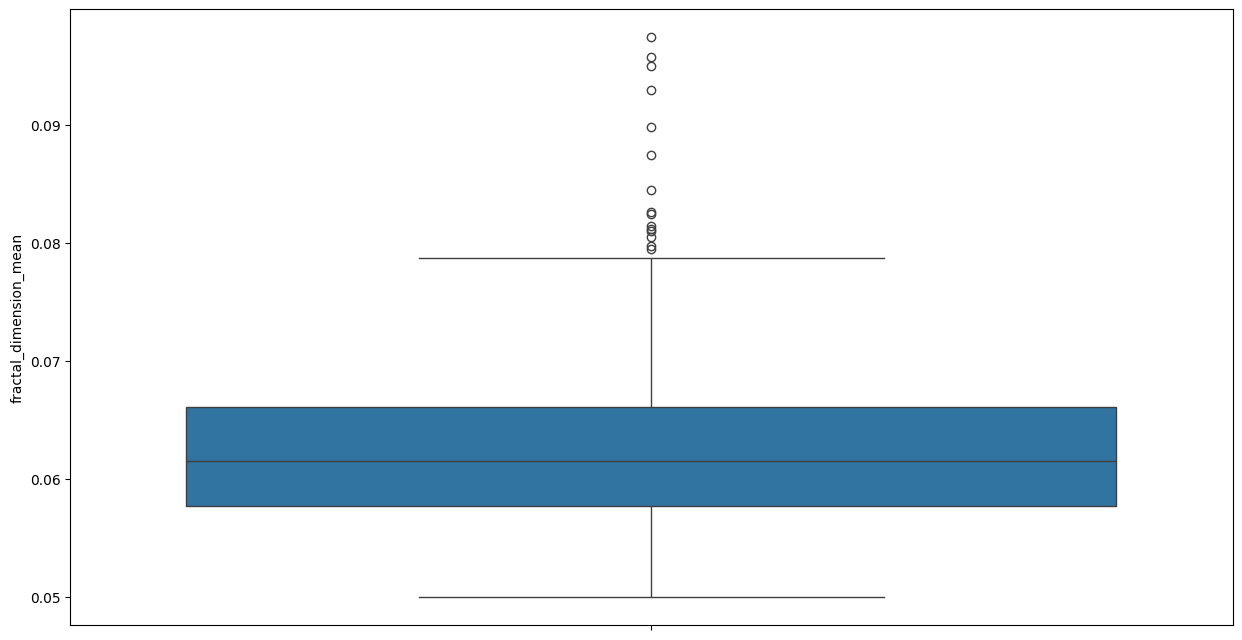

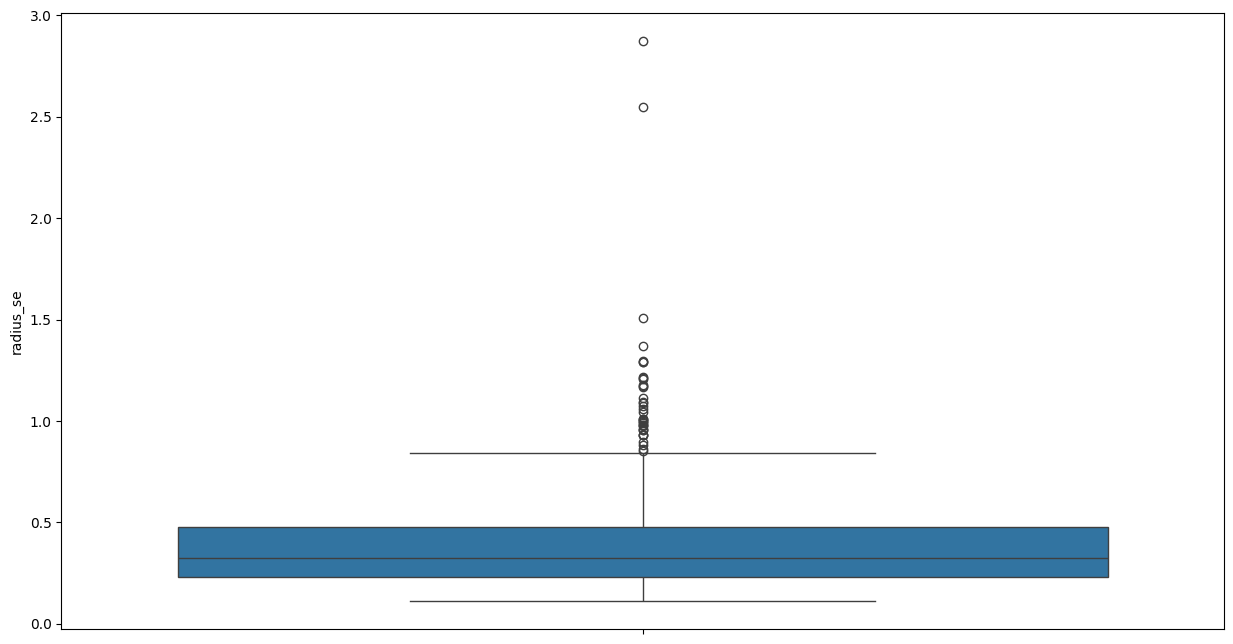

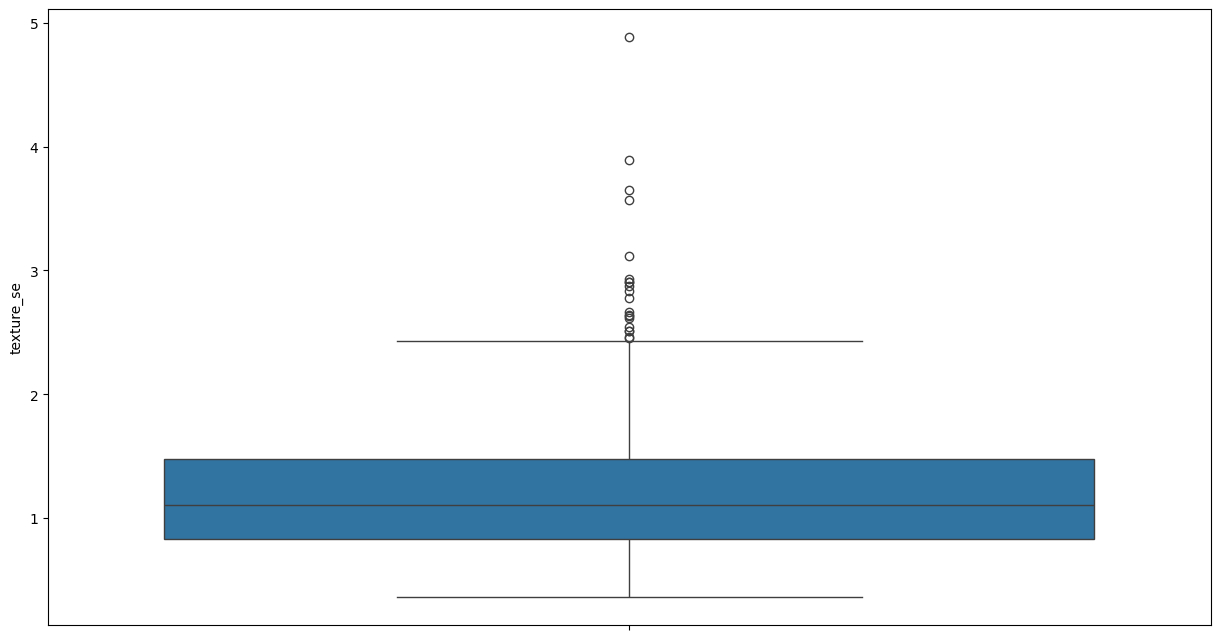

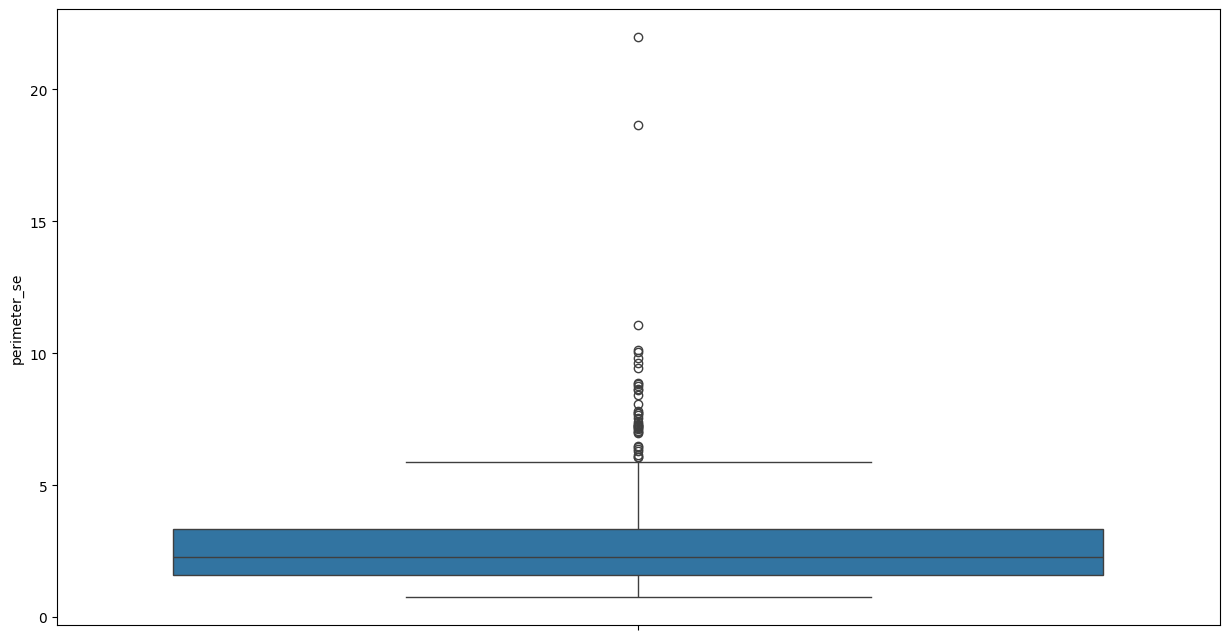

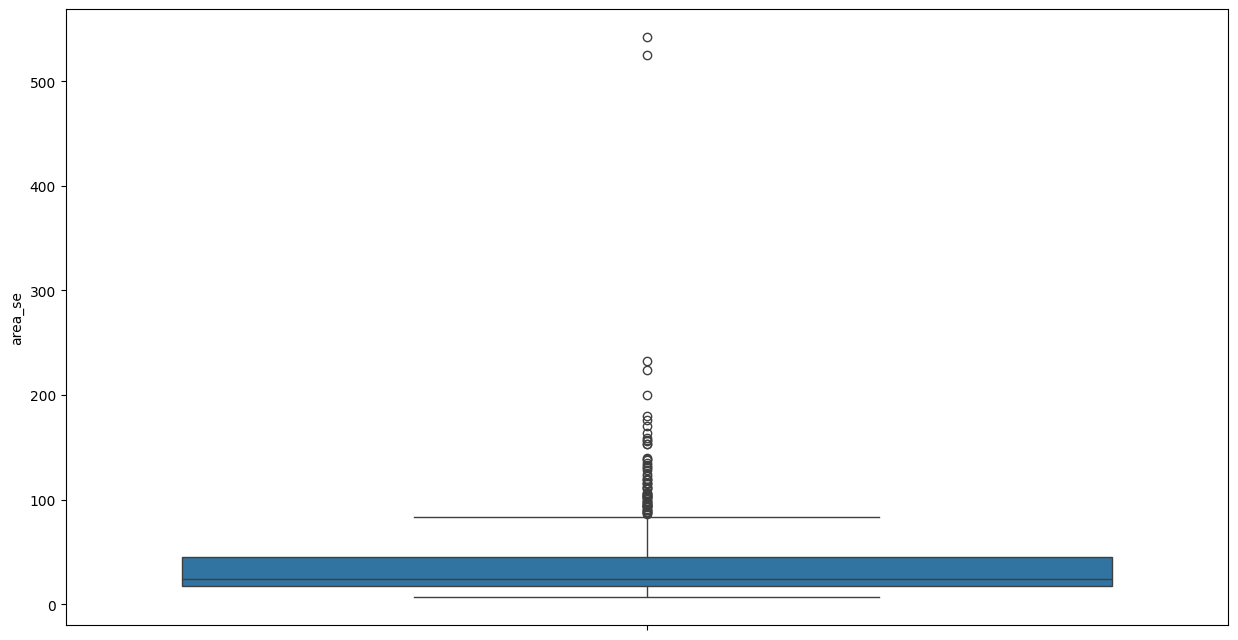

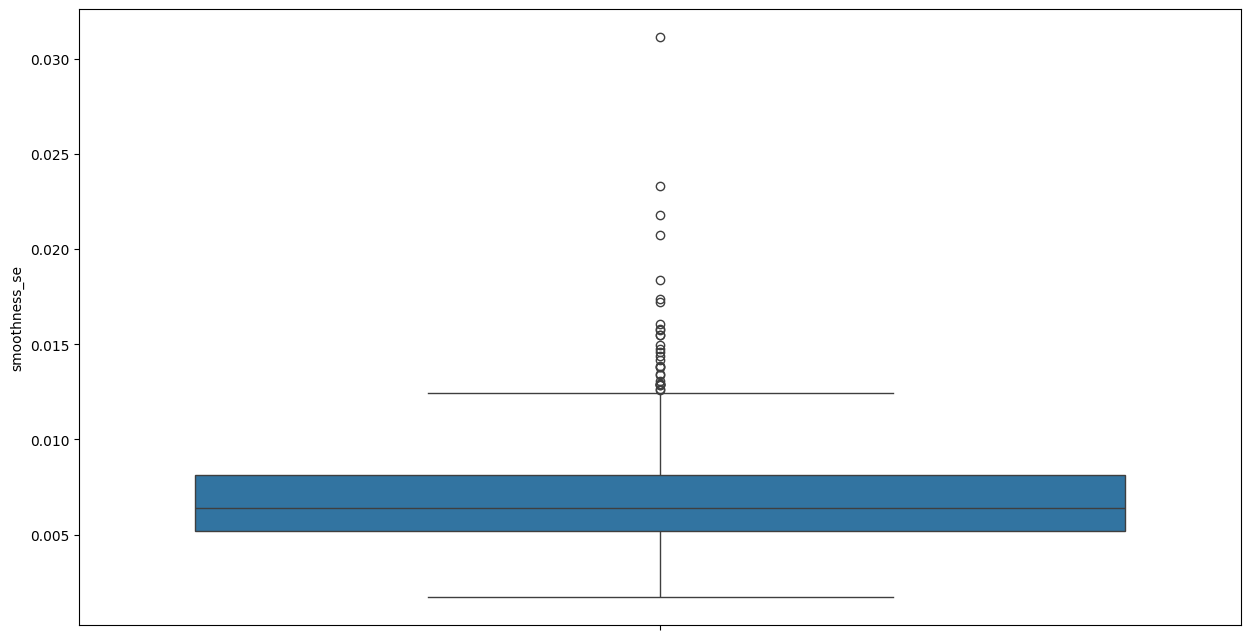

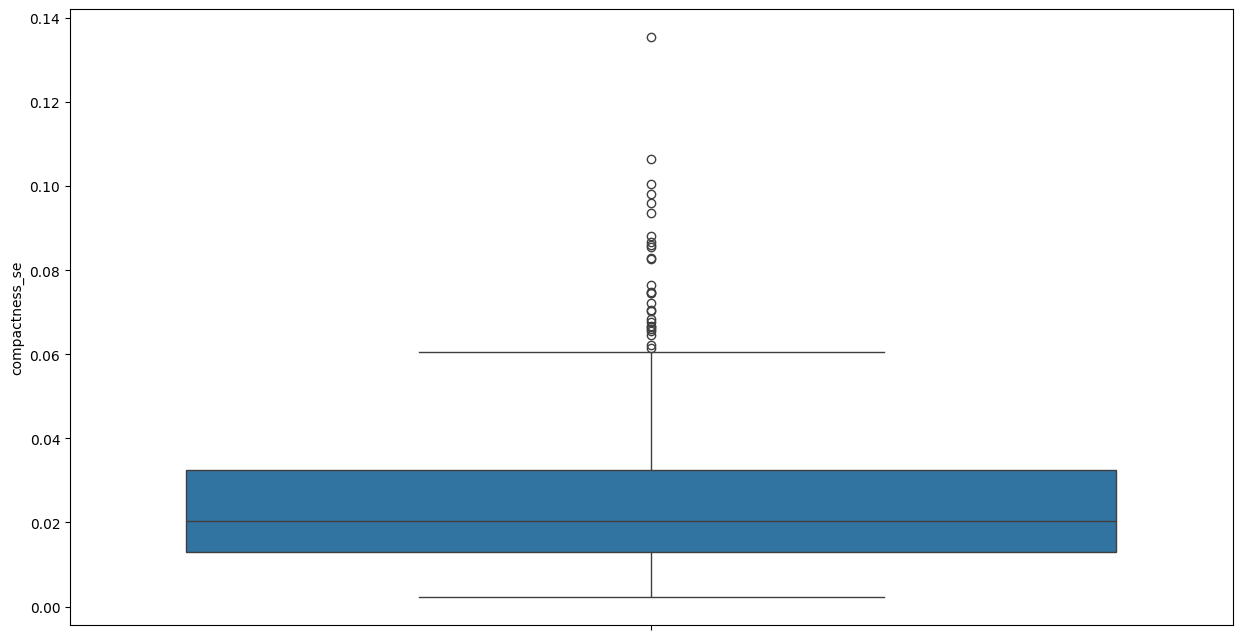

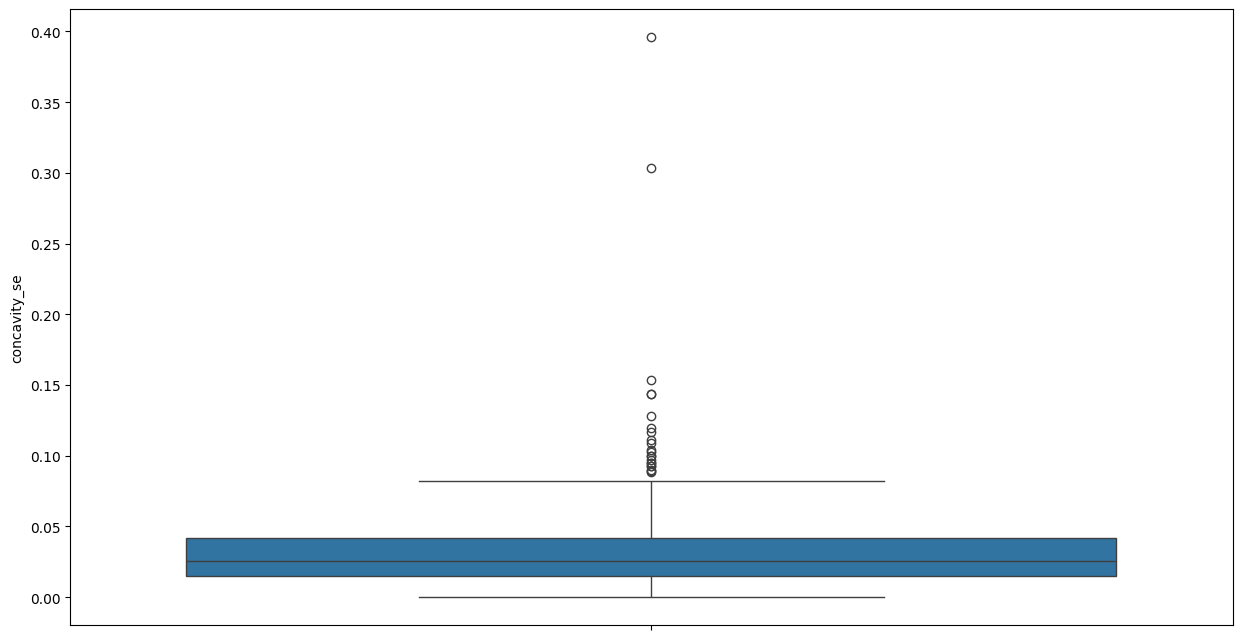

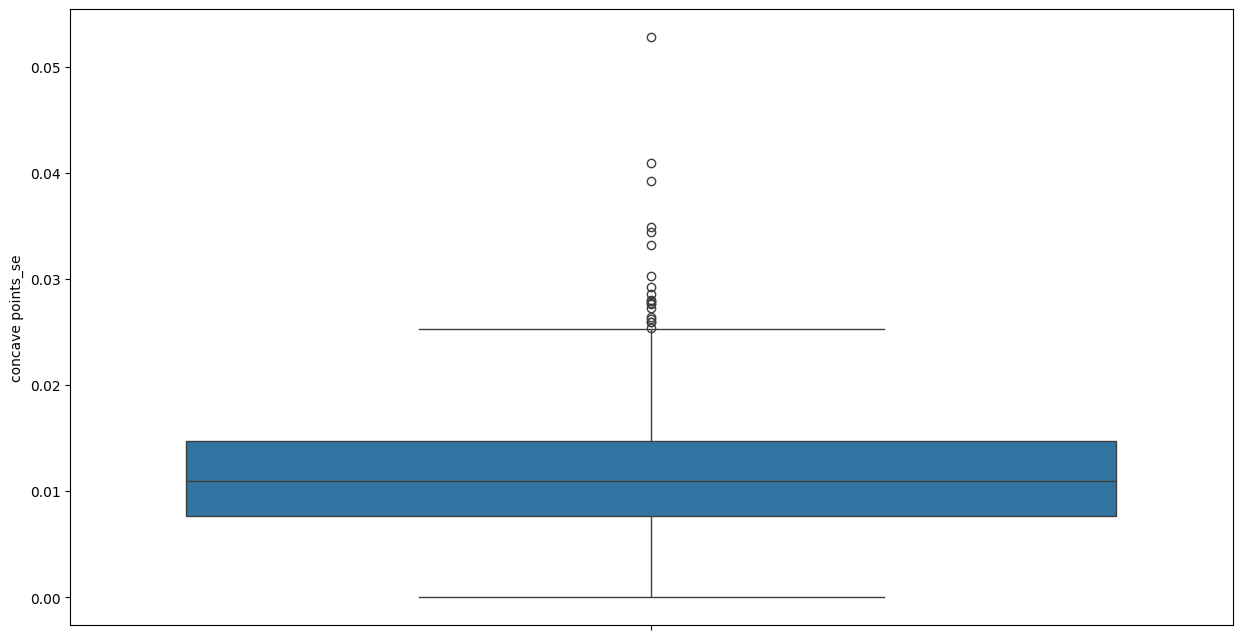

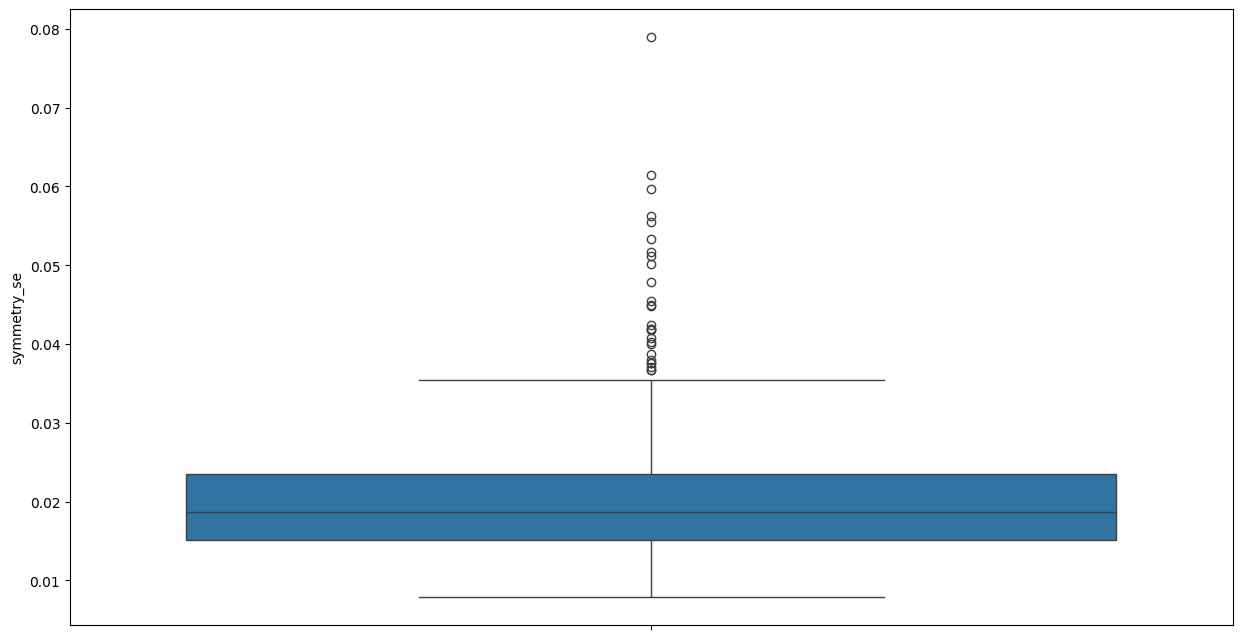

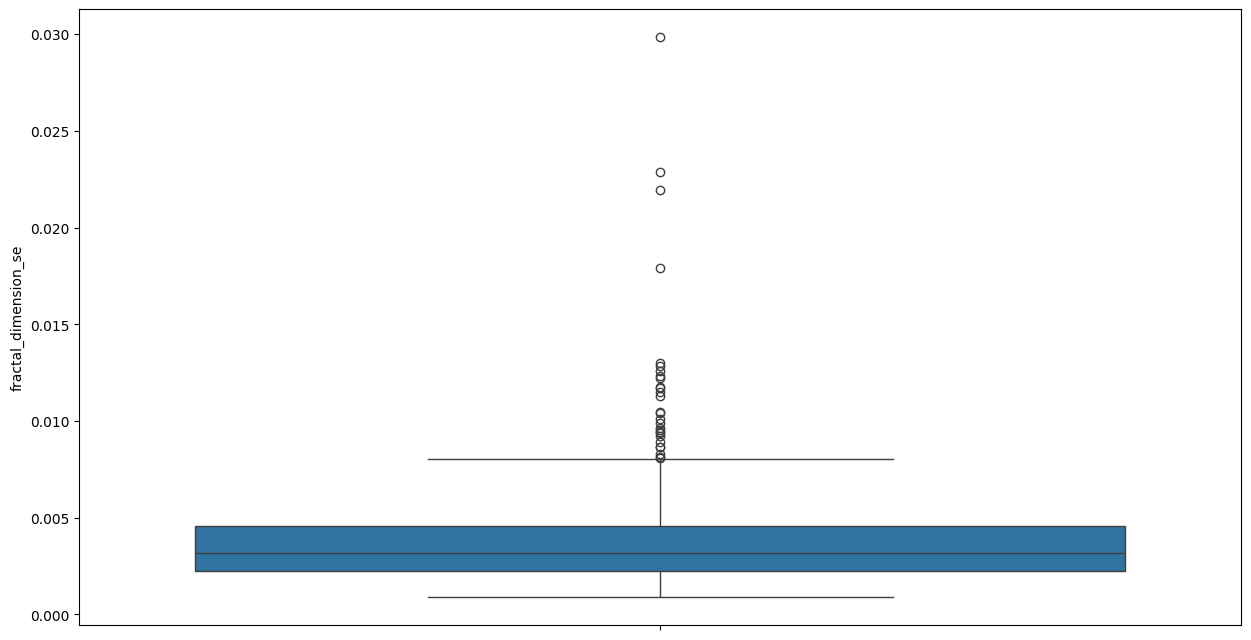

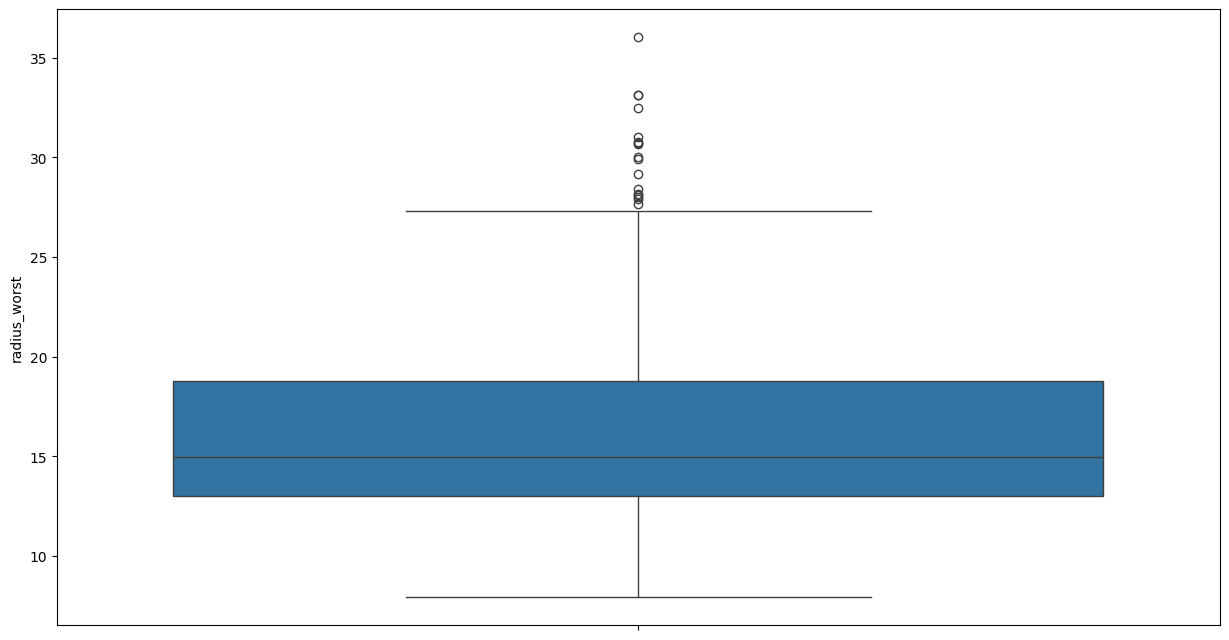

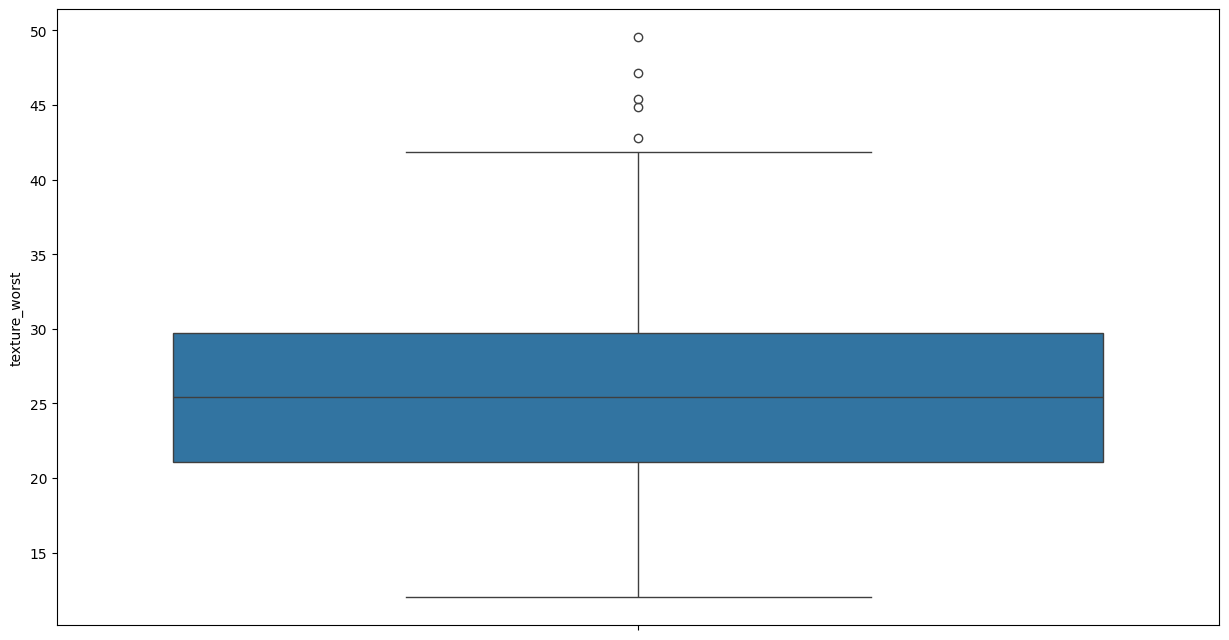

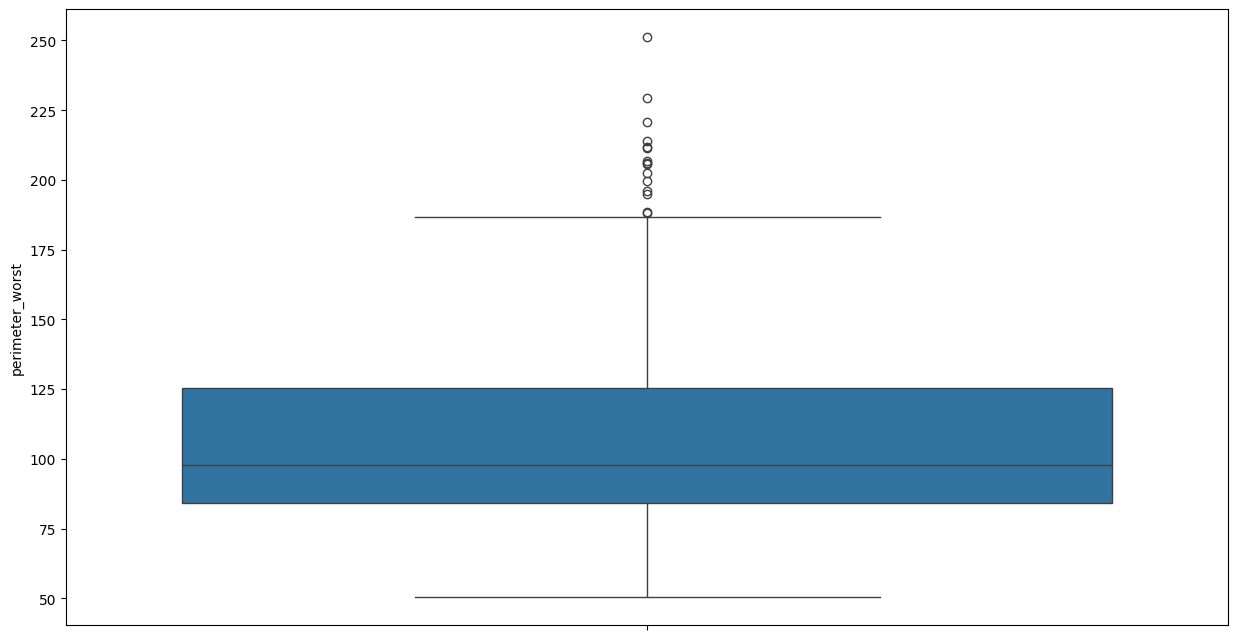

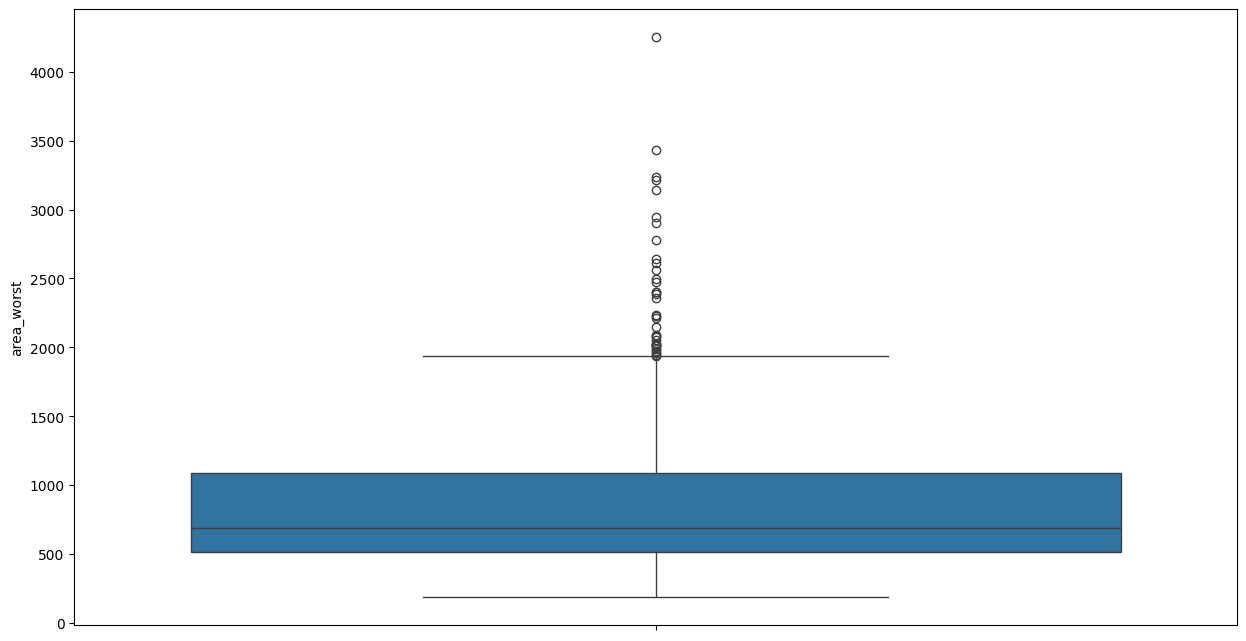

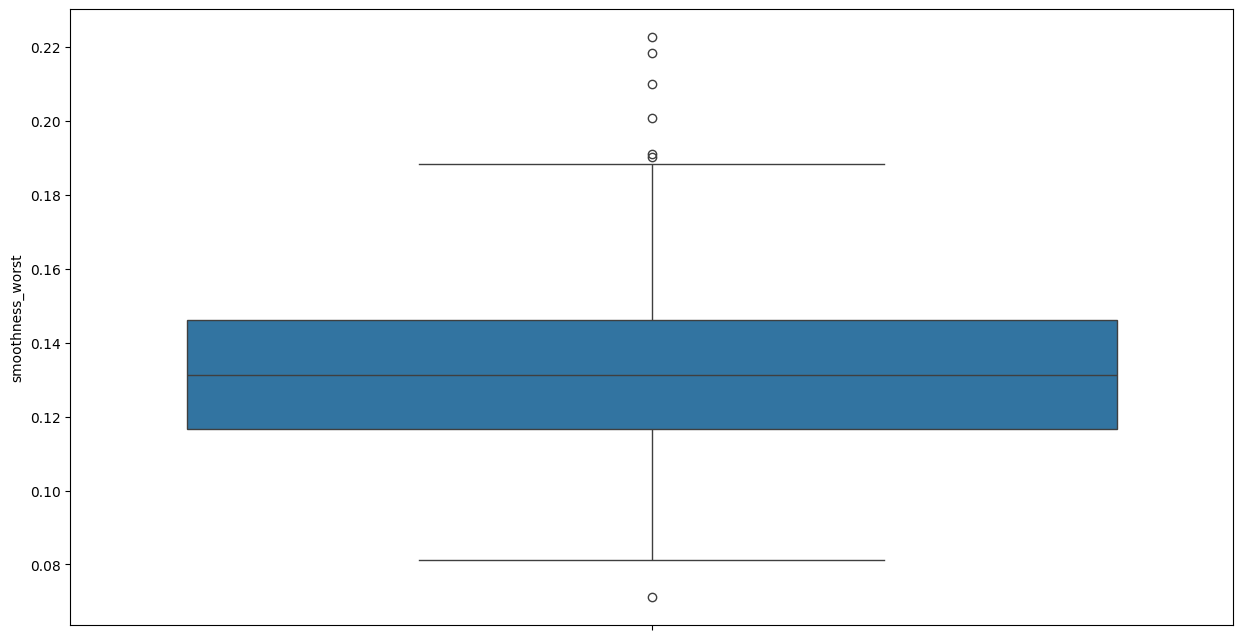

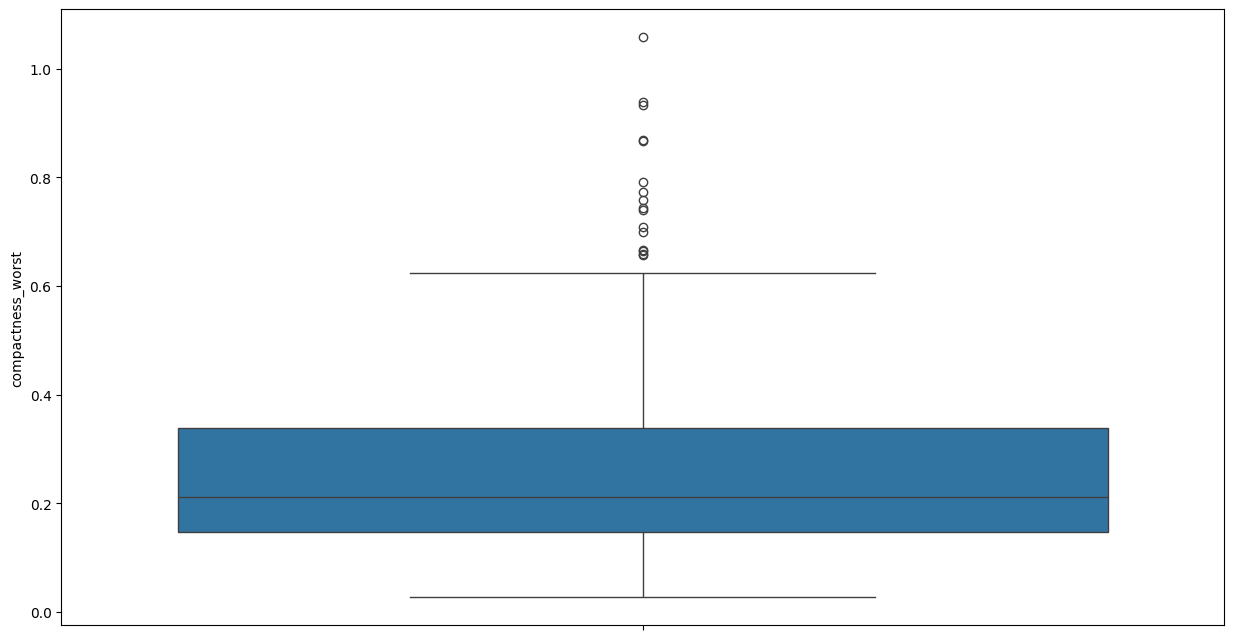

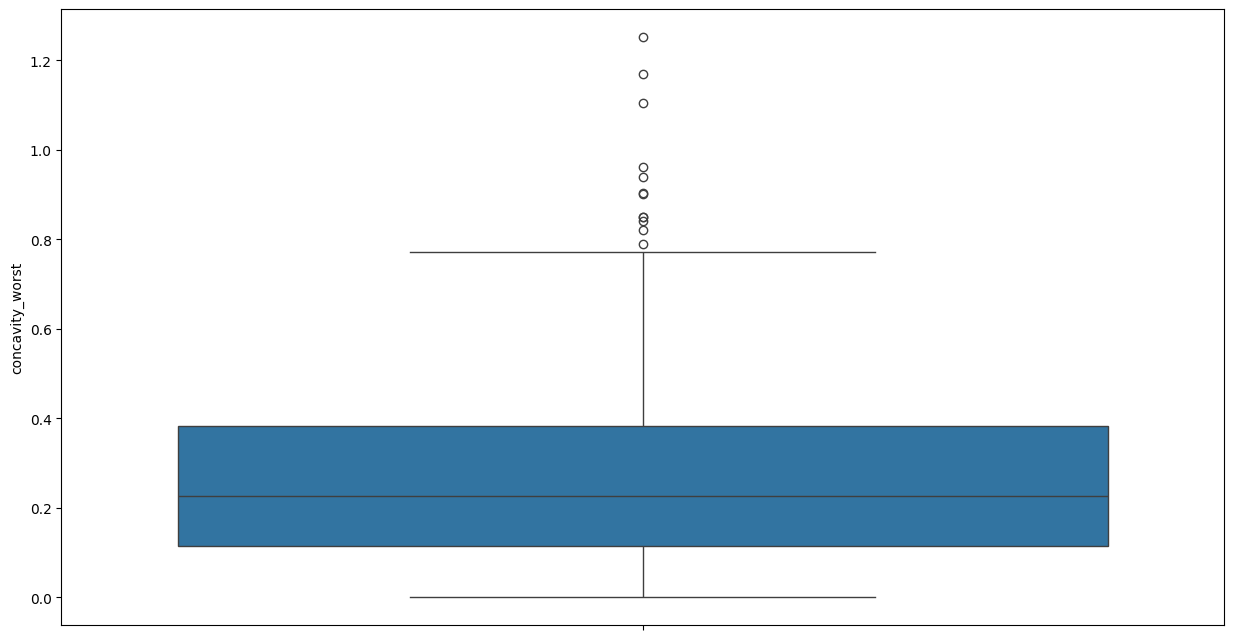

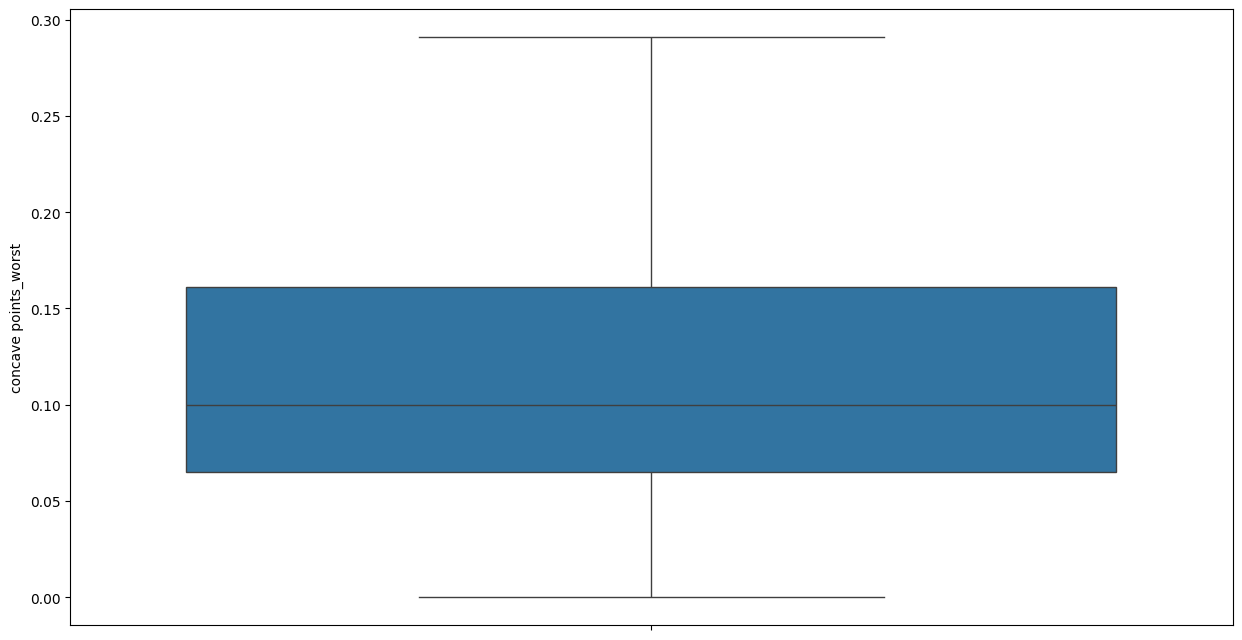

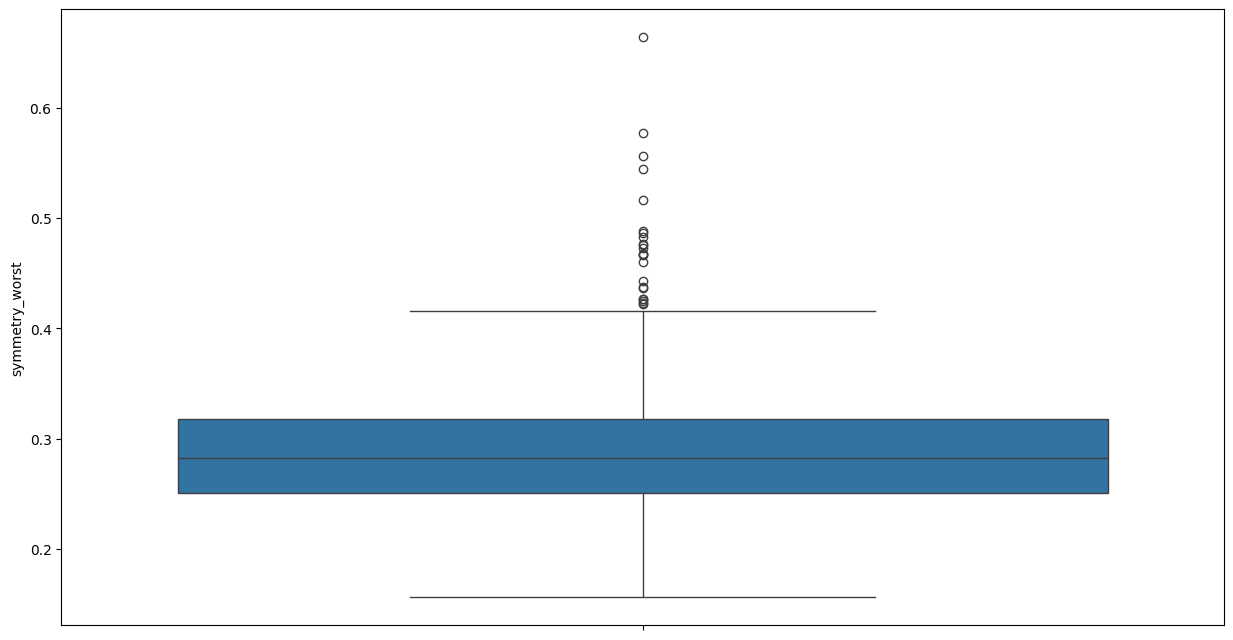

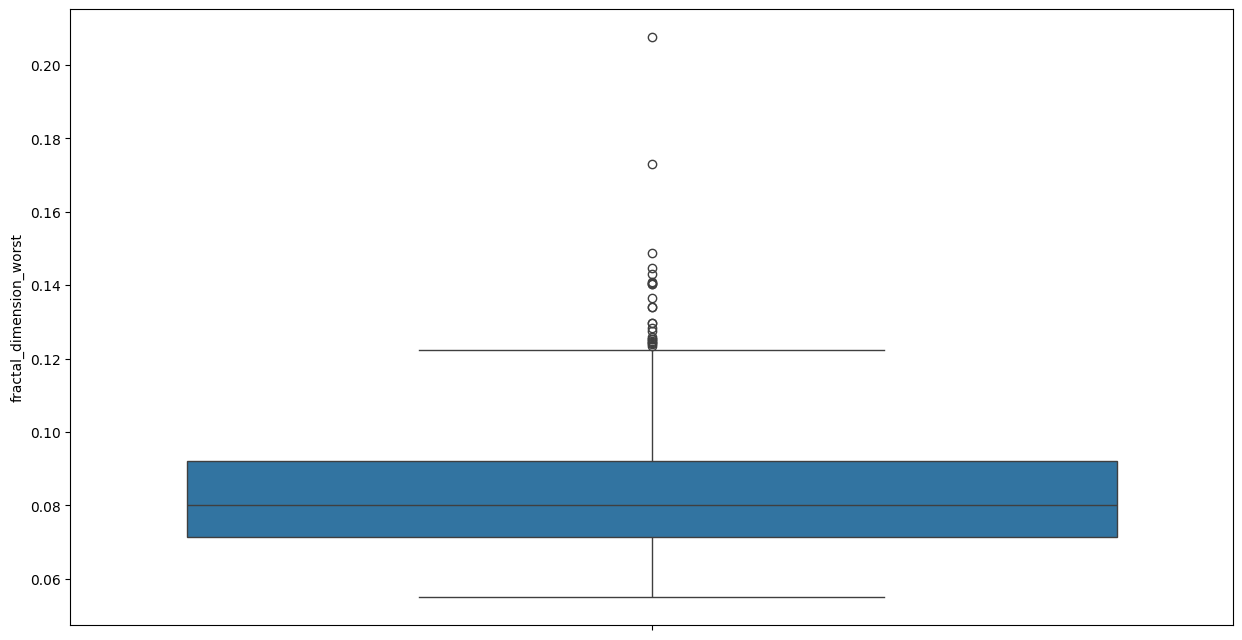

In [72]:
# step2: plot boxplot seperately for each column for better visual
cols_to_exclude = ['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

for col in  df_num.columns:
    plt.figure(figsize=(15,8))
    sns.boxplot(data=df_num[col])
    plt.xticks(rotation=90)
    plt.show()

# obser: we see that there are outliers. 
# Question: I found outliers. I am also performing feature engineering
# to remove highly correlated columns. Should which step should I do first and why
# Answer: 
# - Outliers can distort correlations between features.
# - Example: If one extreme value is present, Pearson correlation (used in df.corr()) might wrongly show a strong correlation.
# - Removing or capping outliers ensures that correlation analysis reflects the true relationship between variables.

In [73]:
# step3: Lets print the outliers

def print_outliers(df):
    """
    Prints outliers for all numeric columns in a DataFrame using IQR.
    """
    
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        print(f"\nColumn: {col}")
        if outliers.empty:
            print("   No outliers found")
        else:
            print(f"   Outliers ({len(outliers)} found):")
            print(outliers.values)

cols_to_exclude = ['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

print_outliers(df_num)


Column: radius_mean
   Outliers (14 found):
[25.22 22.27 24.25 23.27 27.22 23.29 28.11 23.21 23.51 25.73 22.01 27.42
 23.09 24.63]

Column: texture_mean
   Outliers (7 found):
[32.47 33.81 39.28 33.56 31.12 30.72 30.62]

Column: perimeter_mean
   Outliers (13 found):
[171.5 152.8 166.2 152.1 182.1 158.9 188.5 153.5 155.1 174.2 186.9 152.1
 165.5]

Column: area_mean
   Outliers (25 found):
[1404. 1878. 1509. 1761. 1686. 2250. 1685. 2499. 1670. 1364. 1419. 1491.
 1747. 2010. 1546. 1482. 1386. 1335. 1407. 1384. 2501. 1682. 1841. 1347.
 1479.]

Column: smoothness_mean
   Outliers (6 found):
[0.1425  0.1398  0.1447  0.1634  0.1371  0.05263]

Column: compactness_mean
   Outliers (16 found):
[0.2776 0.2839 0.2396 0.2458 0.2293 0.3454 0.2665 0.2768 0.2867 0.2832
 0.2413 0.3114 0.2364 0.2363 0.2576 0.277 ]

Column: concavity_mean
   Outliers (18 found):
[0.3001 0.313  0.3754 0.3339 0.4264 0.3003 0.4268 0.4108 0.2871 0.3523
 0.3201 0.3176 0.2914 0.3368 0.3189 0.3635 0.3174 0.3514]

Column: conc

In [74]:
# step4: I can drop them or cap them. Which is the right approach would be ultimately decided by
# evalution metrics on test dataset
# Here I am capping them.
# TODO for students: Drop them and check the accuracy


def cap_outliers(df):
    """
    Caps outliers for all numeric columns using IQR method.
    Non-numeric columns (e.g., diagnosis) remain unchanged.
    """
    df_capped = df.copy()
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values outside the bounds
        df_capped[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df_capped


# Example usage:
df_capped = cap_outliers(df)   # keep 'diagnosis' + capped numeric features
df = df_capped

In [75]:
# step5: Now reprint the outliers again , and there should be none

def print_outliers(df):
    """
    Prints outliers for all numeric columns in a DataFrame using IQR.
    """
    
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        print(f"\nColumn: {col}")
        if outliers.empty:
            print("   No outliers found")
        else:
            print(f"   Outliers ({len(outliers)} found):")
            print(outliers.values)

cols_to_exclude = ['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

print_outliers(df_num)

# observatin: no outliers. GOOD


Column: radius_mean
   No outliers found

Column: texture_mean
   No outliers found

Column: perimeter_mean
   No outliers found

Column: area_mean
   No outliers found

Column: smoothness_mean
   No outliers found

Column: compactness_mean
   No outliers found

Column: concavity_mean
   No outliers found

Column: concave points_mean
   No outliers found

Column: symmetry_mean
   No outliers found

Column: fractal_dimension_mean
   No outliers found

Column: radius_se
   No outliers found

Column: texture_se
   No outliers found

Column: perimeter_se
   No outliers found

Column: area_se
   No outliers found

Column: smoothness_se
   No outliers found

Column: compactness_se
   No outliers found

Column: concavity_se
   No outliers found

Column: concave points_se
   No outliers found

Column: symmetry_se
   No outliers found

Column: fractal_dimension_se
   No outliers found

Column: radius_worst
   No outliers found

Column: texture_worst
   No outliers found

Column: perimeter_wors

# Data Preprocessing and Feature Engg
**NOTE: I am not doing PCA here, but is done later below.**
- Apply **PCA after correlation reduction**
- Once you have a smaller set of meaningful, non-redundant features, you can run PCA to reduce dimensionality further.
- PCA will then capture genuine variance instead of wasting components on explaining correlations between duplicate-like features.

## Any correlation between variable ?

In [76]:
print(df.corr())

                         diagnosis  radius_mean  texture_mean  perimeter_mean  \
diagnosis                 1.000000     0.745217      0.419123        0.759006   
radius_mean               0.745217     1.000000      0.332760        0.997692   
texture_mean              0.419123     0.332760      1.000000        0.339588   
perimeter_mean            0.759006     0.997692      0.339588        1.000000   
area_mean                 0.752786     0.993891      0.341552        0.991861   
smoothness_mean           0.366931     0.167672     -0.015997        0.204990   
compactness_mean          0.608494     0.502741      0.241666        0.553698   
concavity_mean            0.727168     0.674539      0.318654        0.714624   
concave points_mean       0.788099     0.811833      0.301509        0.841871   
symmetry_mean             0.334536     0.146763      0.079586        0.181325   
fractal_dimension_mean   -0.006801    -0.319056     -0.065946       -0.266586   
radius_se                 0.

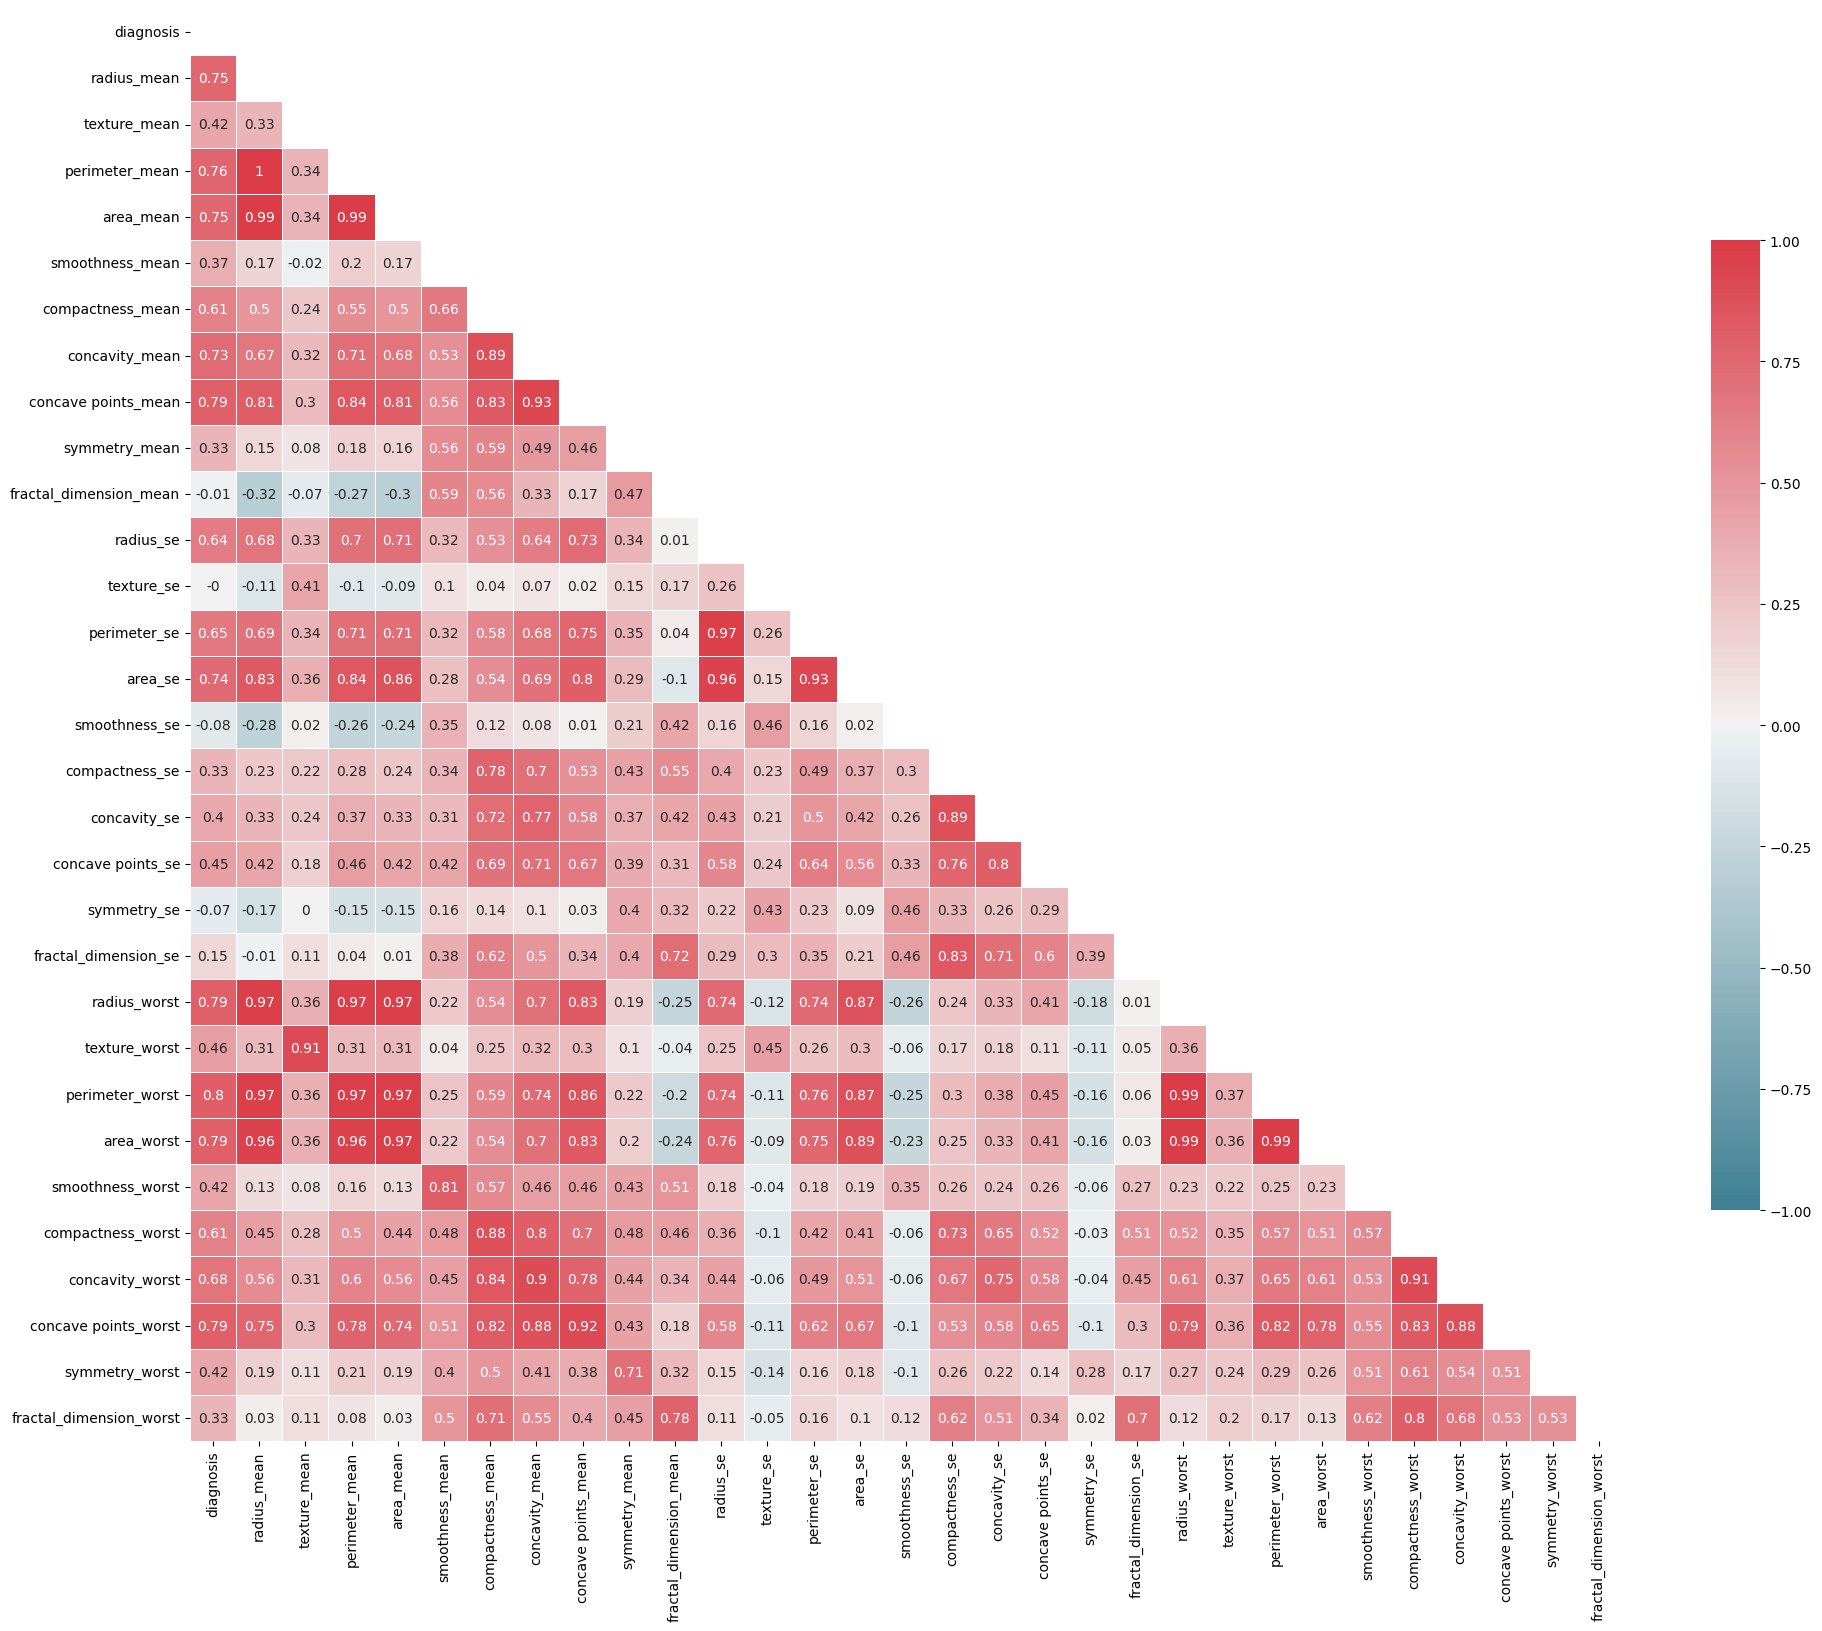

In [77]:
# Let view above via heatmap
# plt.figure(figsize=(20,20))
# plt.title("Correlation Heatmap")
# sns.heatmap(df.corr(), annot=True)

# Generate and visualize the correlation matrix
corr = df.corr().round(2)

# Mask for the upper triangle
# mask = np.zeros_like(corr, dtype=np.bool)
mask = np.zeros_like(corr, dtype=bool)


mask[np.triu_indices_from(mask)] = True

# Set figure size
f, ax = plt.subplots(figsize=(20, 20))

# Define custom colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

plt.tight_layout()

### radius_mean , perimeter_mean, area_mean have a high correlation with malignant tumor

- side note: Ideally you do not include the target variable when trying to find correlation between features 

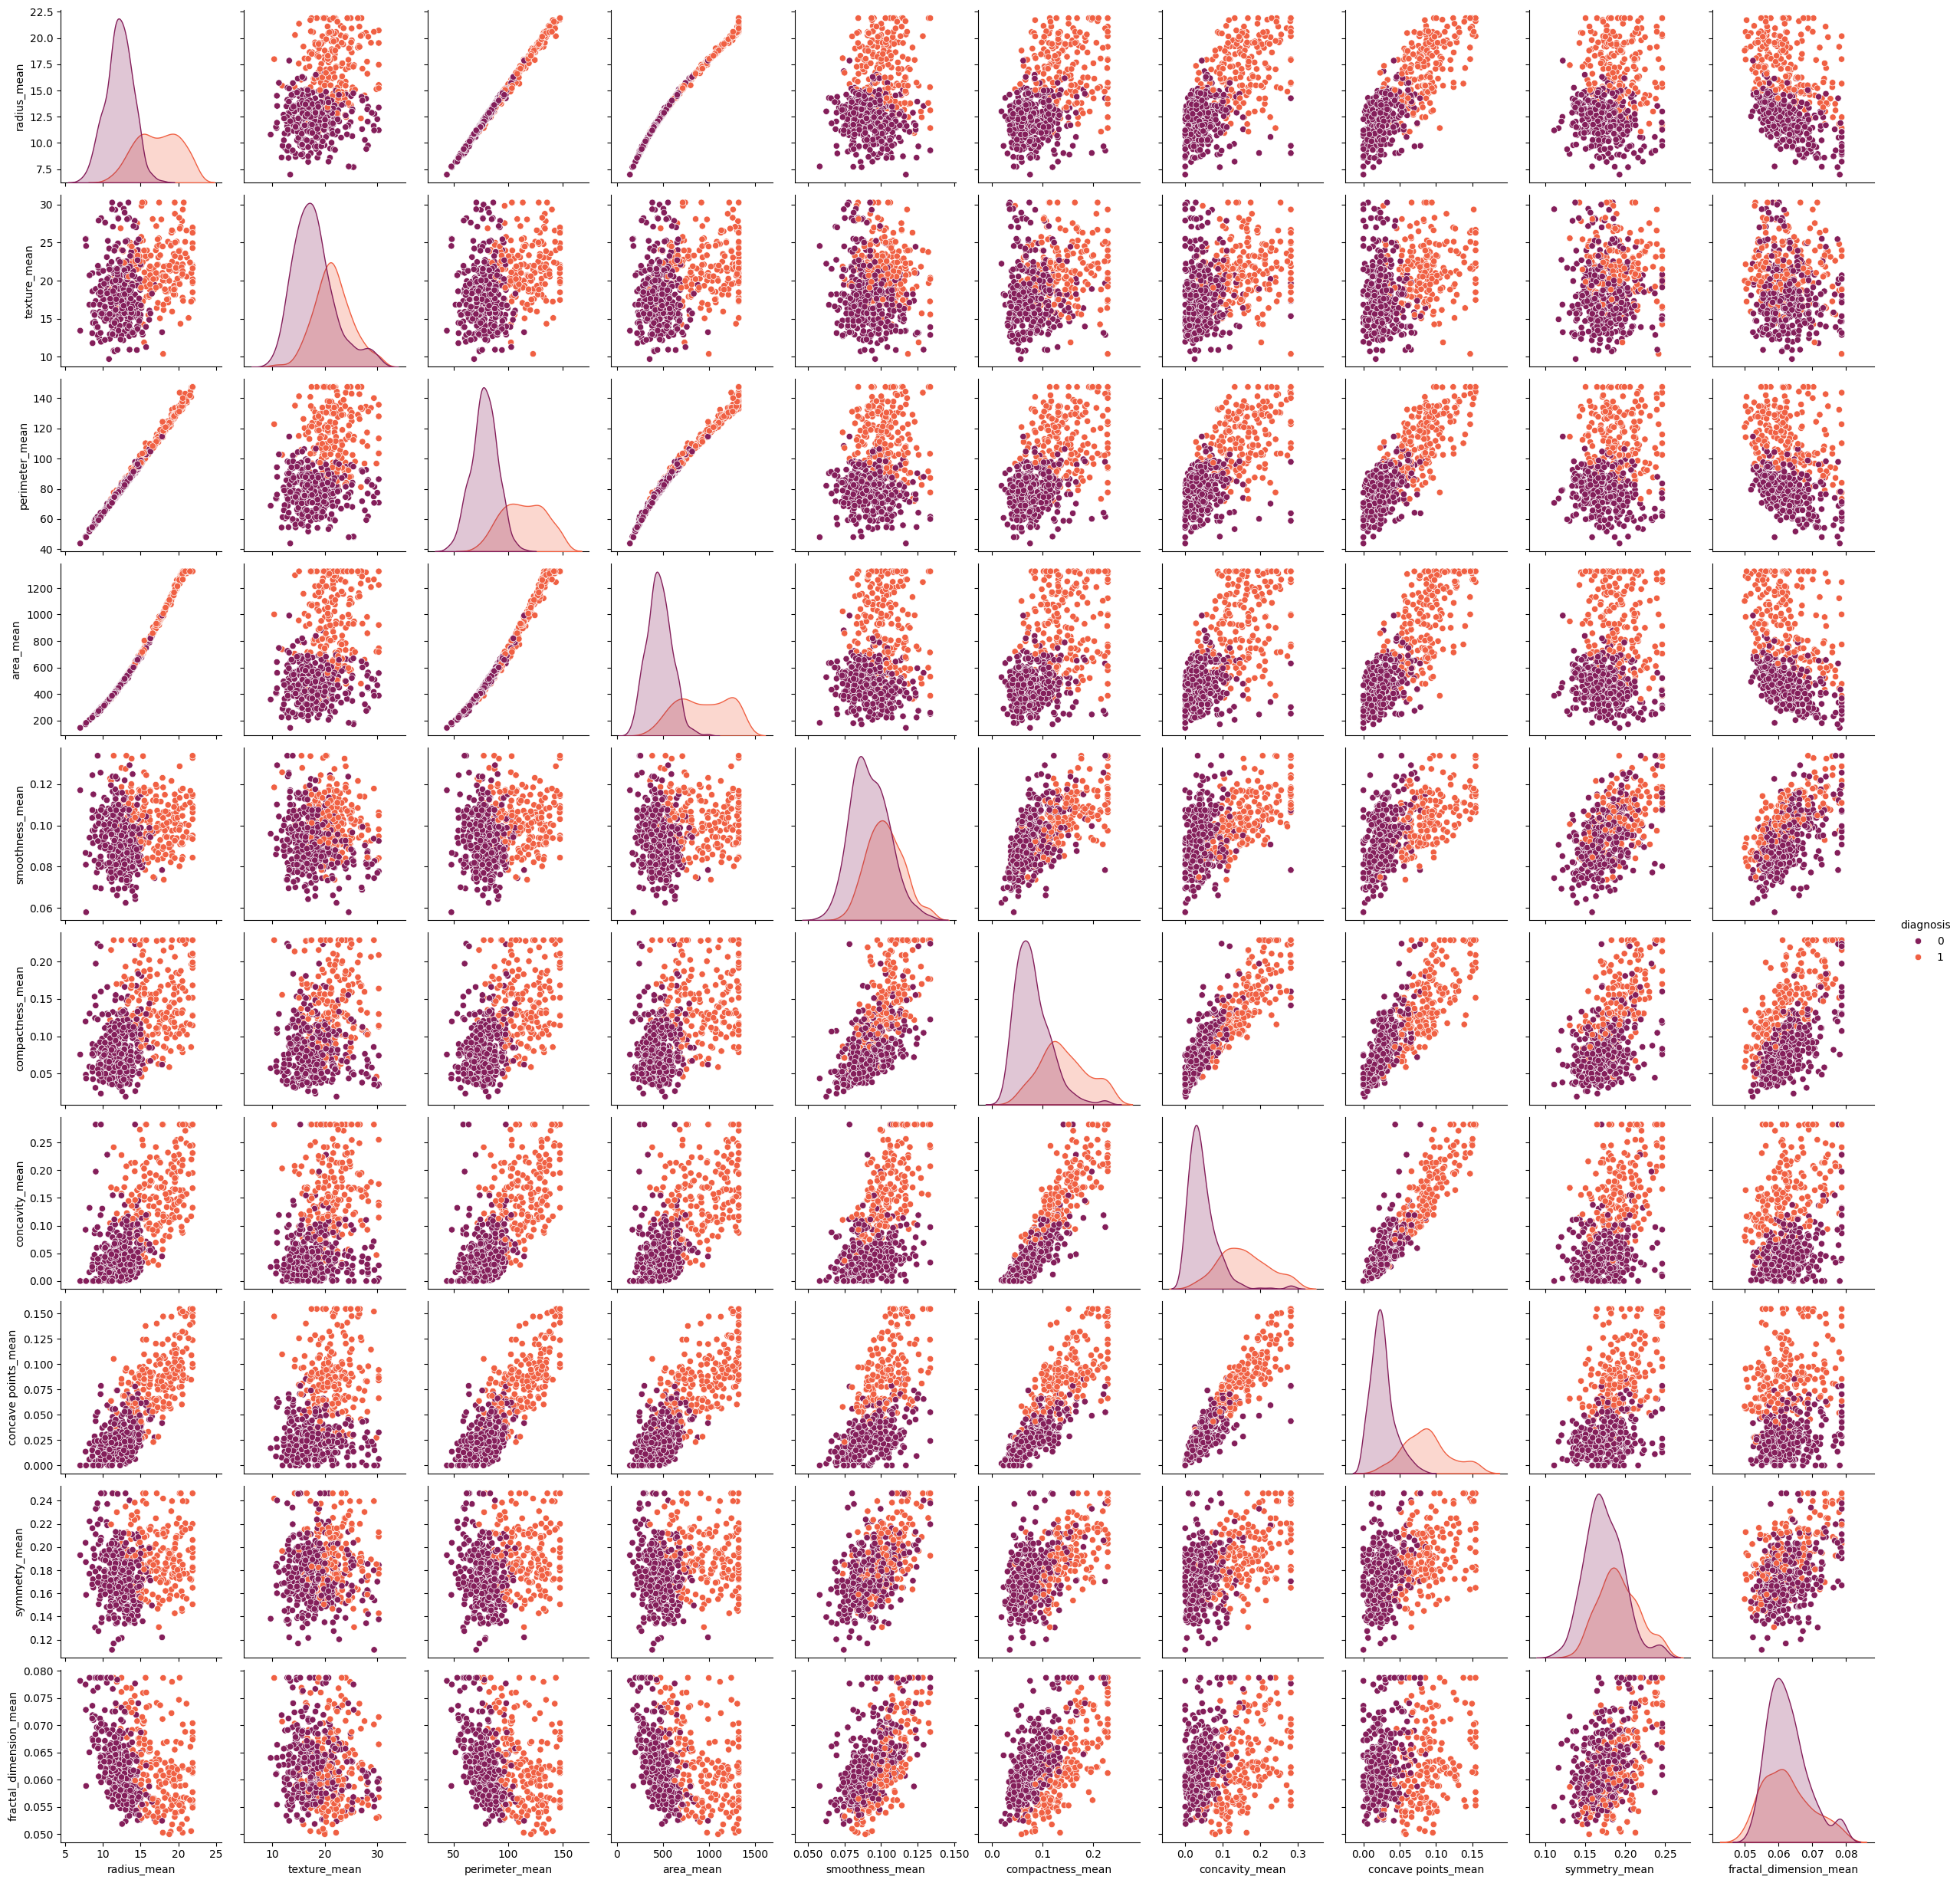

In [78]:
# following took 2 minutes
# generate a scatter plot matrix with the "mean" columns
cols = ['diagnosis',
        'radius_mean', 
        'texture_mean', 
        'perimeter_mean', 
        'area_mean', 
        'smoothness_mean', 
        'compactness_mean', 
        'concavity_mean',
        'concave points_mean', 
        'symmetry_mean', 
        'fractal_dimension_mean']

sns.pairplot(data=df[cols], hue='diagnosis', palette='rocket')

- Almost perfectly linear patterns between the radius_mean, perimeter_mean and area_mean attributes are hinting at the presence of multicollinearity between these variables. (they are highly linearly related). This is to be expected because they all depend on radius,
  
- Another set of variables that possibly imply multicollinearity are the concavity, concave_points and compactness.

we can verify the presence of multicollinearity between some of the variables. 

- For instance, the radius_mean column has a correlation of 1 and 0.99 with perimeter_mean and area_mean columns, respectively.
This is because the three columns essentially contain the same information, which is the physical size of the observation
(the cell). 
Therefore we should only pick ONE of the three columns when we go into further analysis.

- There is multicollinearity between the attributes compactness, concavity, and concave points. So we can choose just ONE out of these, I am going for Compactness.

- Here we drop col ending with _worst. Dropping _worst columns is done to remove redundancy in the feature set, especially when the mean or standard deviation values already provide enough information.

In [79]:
# first, drop all "worst" columns because they are redundant
cols = ['radius_worst', 
        'texture_worst', 
        'perimeter_worst', 
        'area_worst', 
        'smoothness_worst', 
        'compactness_worst', 
        'concavity_worst',
        'concave points_worst', 
        'symmetry_worst', 
        'fractal_dimension_worst']
df = df.drop(cols, axis=1)

# then, drop all columns related to the "perimeter" and "area" attributes
cols = ['perimeter_mean',
        'perimeter_se', 
        'area_mean', 
        'area_se']
df = df.drop(cols, axis=1)

# lastly, drop all columns related to the "concavity" and "concave points" attributes
cols = ['concavity_mean',
        'concavity_se', 
        'concave points_mean', 
        'concave points_se']
df = df.drop(cols, axis=1)

# verify remaining columns
print(df.columns)

Index(['diagnosis', 'radius_mean', 'texture_mean', 'smoothness_mean',
       'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'smoothness_se', 'compactness_se',
       'symmetry_se', 'fractal_dimension_se'],
      dtype='object')


In [80]:
# SIDE NOTE: We can automate this process:

def drop_highly_correlated_features(df, threshold=0.7):
    """
    Drops columns with correlation coefficient greater than the given threshold.
    
    Parameters:
    df : pandas.DataFrame
        Input dataframe
    threshold : float
        Correlation threshold (default = 0.7)
    
    Returns:
    df_reduced : pandas.DataFrame
        DataFrame after dropping highly correlated columns
    dropped_features : list
        List of dropped column names
    """
    
    # Compute correlation matrix (numeric columns only)
    corr_matrix = df.select_dtypes(include=np.number).corr().abs()
    
    # Get upper triangle of correlation matrix
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Identify columns to drop
    dropped_features = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > threshold)
    ]
    
    # Drop columns
    df_reduced = df.drop(columns=dropped_features)
    
    return df_reduced, dropped_features


df_reduced, dropped_cols = drop_highly_correlated_features(df, threshold=0.7)

print("Dropped columns:", dropped_cols)
print("Remaining columns:", df_reduced.columns.tolist())


Dropped columns: ['radius_mean', 'compactness_se', 'fractal_dimension_se']
Remaining columns: ['diagnosis', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'symmetry_se']


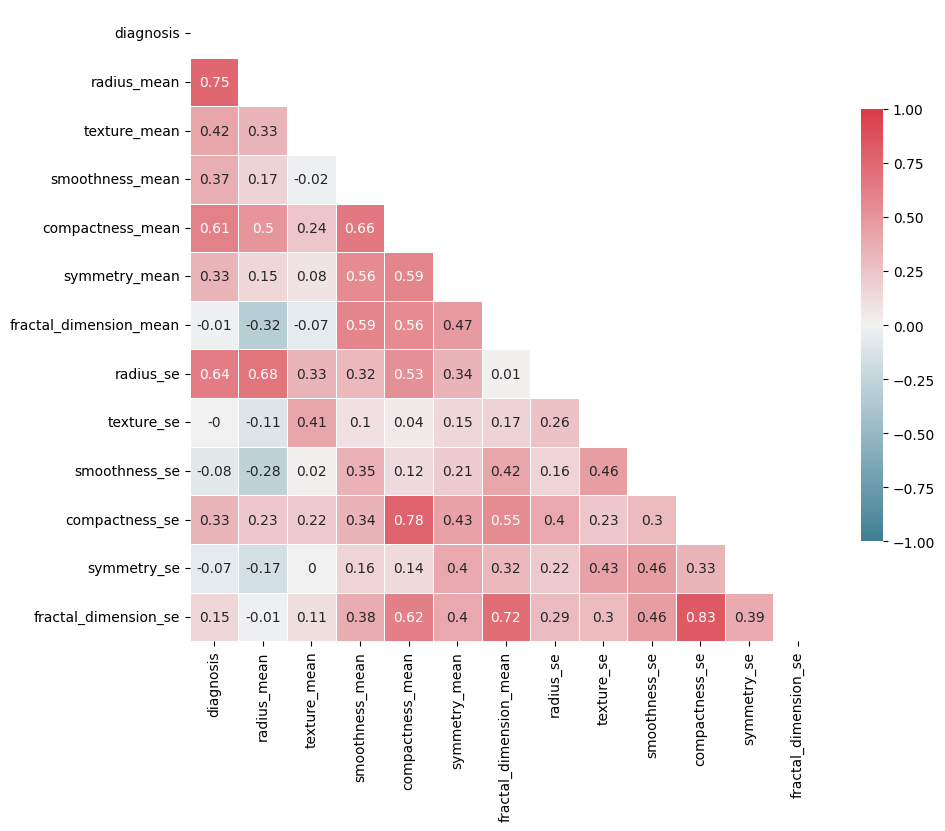

In [81]:
# Draw the heatmap again, with the new correlation matrix

corr = df.corr().round(2)
# mask = np.zeros_like(corr, dtype=np.bool)
mask = np.zeros_like(corr, dtype=bool)

mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
plt.tight_layout()

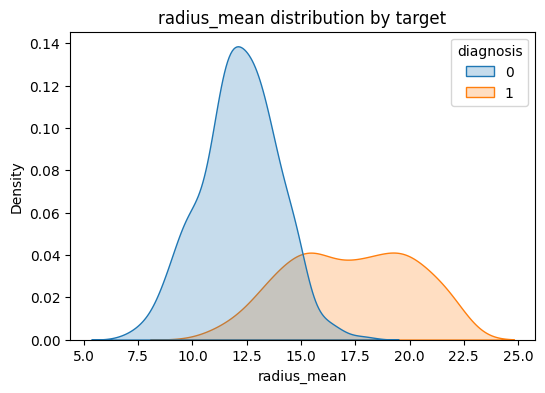

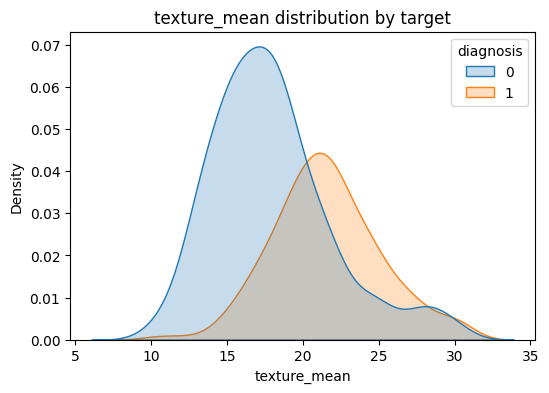

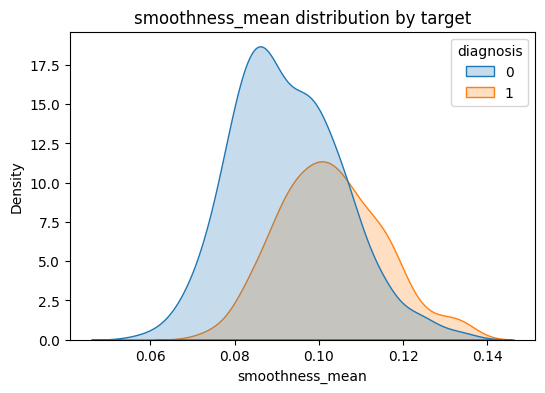

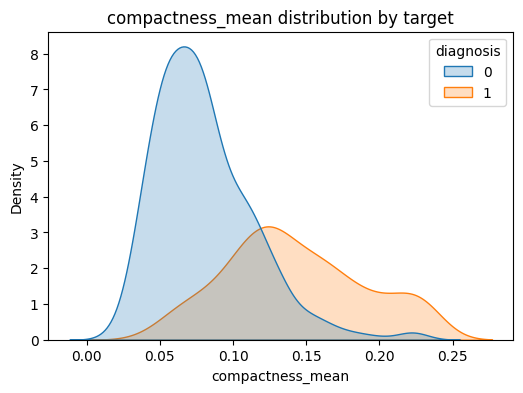

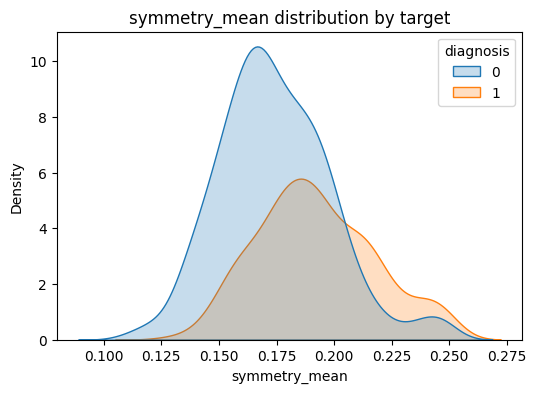

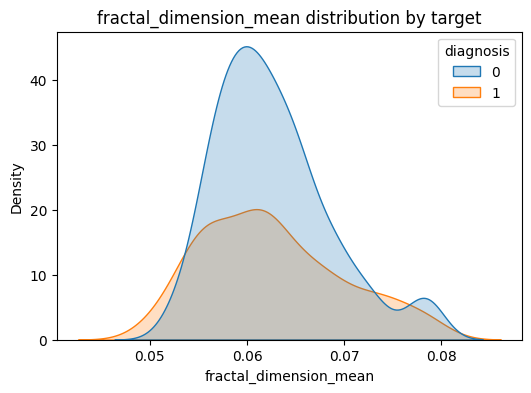

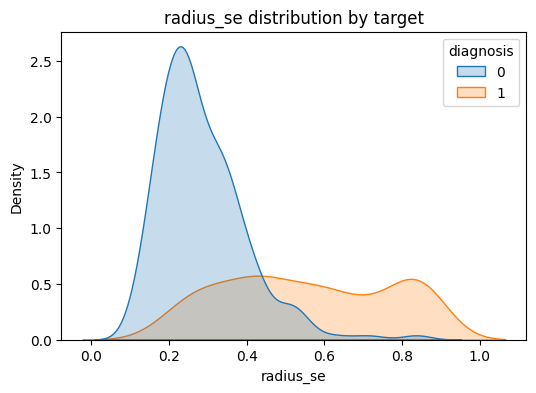

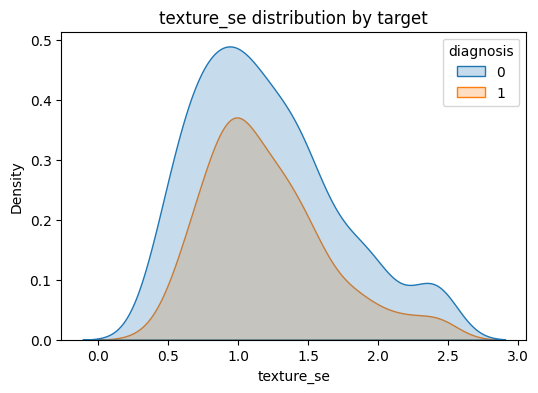

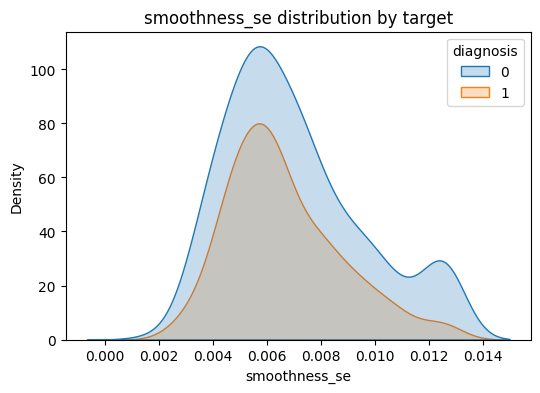

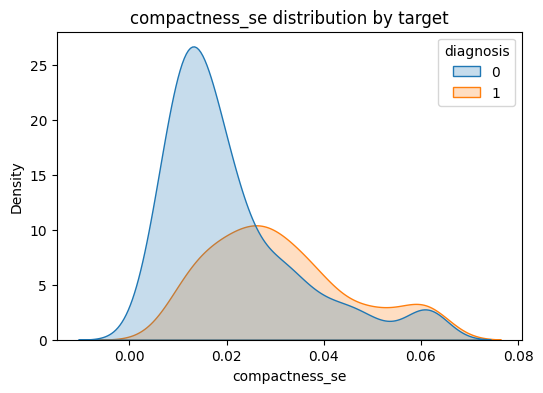

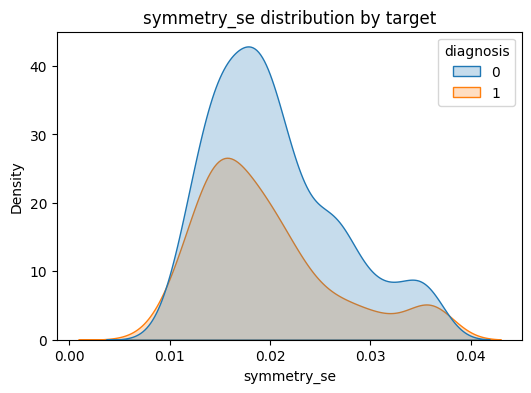

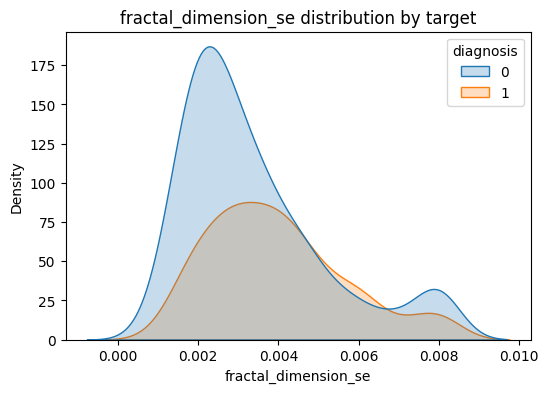

In [82]:
# Now lets do Target-wise Distribution again
cols_to_exclude = ['diagnosis']  
df_num = df.drop(columns=cols_to_exclude)

for col in df_num.columns:  # excluding target
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue='diagnosis', fill=True)
    plt.title(f'{col} distribution by target')
    plt.show()

# observation:
# If two classes have very different distributions, that feature is discriminative.
# radius_mean, radius_worst, perimeter_worst, concave_points_worst,etc separates malignant (higher values) vs benign (lower values).

### Now we should use PCA to perform feature reduction here. PCA should be done after correlation reduction
- PCA works by finding directions (components) that maximize variance.
- If you have highly correlated features, PCA will heavily weigh those features and the components may be dominated by redundant variables.
- By removing highly correlated features first, you reduce redundancy and noise, which leads to cleaner and more interpretable PCA results.


So first step: feature engineering -> drop/reduce highly correlated features.

(I am not doing this here...I do it below to show how it is done)

# Logistic Regression

## Preprocessing

Now we can proceed to train our model. The first thing to do is to do is to separate the target variable (here called "y") and the features  or predictors(here called "X"). Note that we use an uppercase X as convention in order to mymic the mathematical language. In mathematics, an uppercase symbol represents that the variable is multidimensional (a matrix).

In [83]:
# Prepare the model
X = df.drop(["diagnosis"], axis=1) # our predictors
y = df["diagnosis"] # our target variable

In [84]:
# Lets look at one data point
print(X.iloc[0, :])
print(list(X.iloc[0, :]))

radius_mean               17.990000
texture_mean              10.380000
smoothness_mean            0.118400
compactness_mean           0.228620
symmetry_mean              0.241900
fractal_dimension_mean     0.078710
radius_se                  0.848650
texture_se                 0.905300
smoothness_se              0.006399
compactness_se             0.049040
symmetry_se                0.030030
fractal_dimension_se       0.006193
Name: 0, dtype: float64
[17.99, 10.38, 0.1184, 0.22861999999999996, 0.2419, 0.07871, 0.84865, 0.9053, 0.006399, 0.04904, 0.03003, 0.006193]


## Normalize the data

You might be tempted to use this data to perform the train-test split directly. But wait! The data is not yet normalized. This can be a problem, because the units of our variables are not necessarily in the same units. Also, there might be some outliers that could cause our model to perform badly. 

What we do in these cases is normalize the data before feeding it into our model. This will improve the performance of our machine learning algorithm. 

In [85]:
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()

# Fit the scaler to the data and transform the data
X_scaled = scaler.fit_transform(X)

# X_scaled is now a numpy array with normalized data

## 6. Data Split

We then split the dataset into a training set and a testing set. Both have the same variables (columns), but different observations (rows). To do this, we use a very conveninent Scikit-Learn function called `train_test_split`. This function takes our predictors and our target variable and splits them into a testing set and a training set randomly. It returns 4 values:

- The predictors of our training set. We store this in a python variable that we call `X_train`.
- The targets of our training set. We will store them in a python variable that we call `y_train`. 
- The predictors of our testing set. We will store them in a python variable that we call `X_test`.
- The targets of our testing set. We will store them in a python variable that we call `y_test`. 

In them, each observation (row) in `X` corresponds to the target value in `y`.

Other parameters that our function `train_test_split` takes are `test_size` and `random_state`:
- `train_test_split` sets the size of our `X_test` and its `y_test`. 
- `random_state`, which is an arbitrary integer that will allow us to replicate the split if we ever need to perform the exact random split again. We usually choose 42 because it is the answer to everything.

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

## 7. Modelling and Training

In [87]:
from sklearn.linear_model import LogisticRegression

# Create logistic regression model
model = LogisticRegression()

# Train the model on the training data
model.fit(X_train, y_train)

LogisticRegression()

In [88]:
# TODO: Test it on 1 data point. Make the data point normalize and then feed it into prediction model
data = np.array([17.99, 10.38, 0.1184, 0.22861999999999996, 0.2419, 0.07871, 0.84865, 0.9053, 0.006399, 0.04904, 0.03003, 0.006193]).reshape(1, -1)
data_scaled = scaler.fit_transform(data)
pred = model.predict(data_scaled)
print(pred)

[0]


## 8. Model Evaluation

In this notebook, we have trained a logistic regression model to predict the target variable using a dataset of input features. As you can see here, after training the model on the training set and evaluating its performance on the test set, we achieved a final accuracy of 0.98. This is a strong performance and indicates that the model is able to make accurate predictions on new, unseen data. 

However, it's important to note that accuracy is just one measure of a model's performance, and it may not be the most appropriate measure for all problems. Depending on the problem and the specific requirements of the application, other metrics such as precision, recall, or F1 score may be more relevant. In the second cell, we use the `classification_report` function from `Scikit-learn` to calculate those measures. 

In [89]:
from sklearn.metrics import accuracy_score

# Predict the target variable on the test data
y_pred = model.predict(X_test)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.96


### Thats great

#### Side note
**The accuracy may be increased by not dropping columns that we dropped. As the columns were dropped we lost some information.**

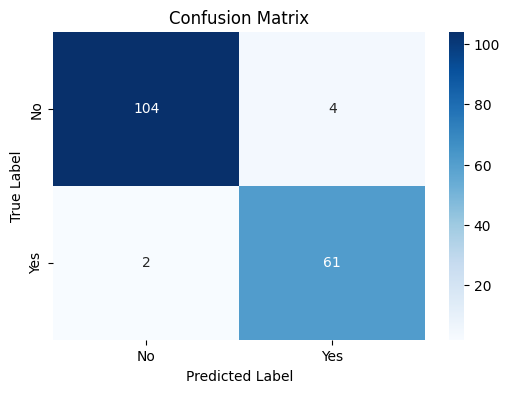

In [92]:
# 1) lets plot confusion matrix: 

from sklearn.metrics import confusion_matrix

# Assuming these are your test labels and predictions
y_pred = model.predict(X_test)  # Predicted labels
cm = confusion_matrix(y_test, y_pred)  # Compute confusion matrix

# Plot the confusion matrix using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


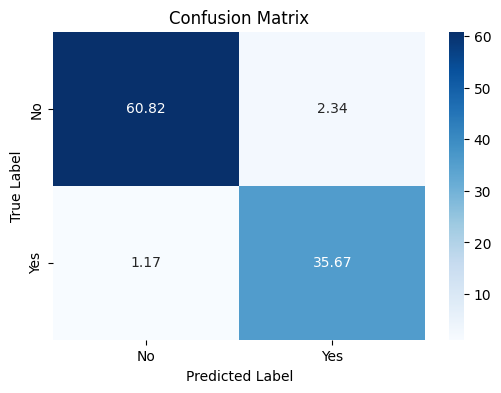

In [94]:
# 2) Normalize the confusion matrix (convert to percentages)

cm_percentage = cm.astype('float') / cm.sum() * 100  # 

plt.figure(figsize=(6, 4))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [41]:
#$ Lets print the classificatiin report

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       108
           1       0.94      0.97      0.95        63

    accuracy                           0.96       171
   macro avg       0.96      0.97      0.96       171
weighted avg       0.97      0.96      0.97       171



- High Precision (~0.97): Few false positives (incorrect positive predictions).
- High Recall (~0.96): Model captures most actual positives, missing very few.
- High F1-score (~0.97): Good balance between precision & recall.
- Accuracy (0.96): 96% of total predictions were correct.
- Macro vs. Weighted Avg:
   1. If classes are balanced, both values are similar.
   2. If imbalance exists, weighted avg is more meaningful.

# Conclusion

We have finished our analysis. We have used the data from the open dataset Breast Cancer in order to build a model that will predict if a given cell is malicious or not given certain measurements of its nucleus. This model, now that it is trained, can, evidently, be extremely useful to perform punctual analysis on given cells for a hospital.

### Next step:
- Deployment: This kind of model can easily be added to a server technology such as Flask and serve a front-end application that doctors can use. For example, we could build an interface where a doctor inputs some measurements that she has performed and the model would output if the cell is malicious or not.

### OPTIONAL: FURTHER STEPS with PCA

In [42]:
# lets see which columns I am working with now:
print(df.columns)

Index(['diagnosis', 'radius_mean', 'texture_mean', 'smoothness_mean',
       'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'smoothness_se', 'compactness_se',
       'symmetry_se', 'fractal_dimension_se'],
      dtype='object')


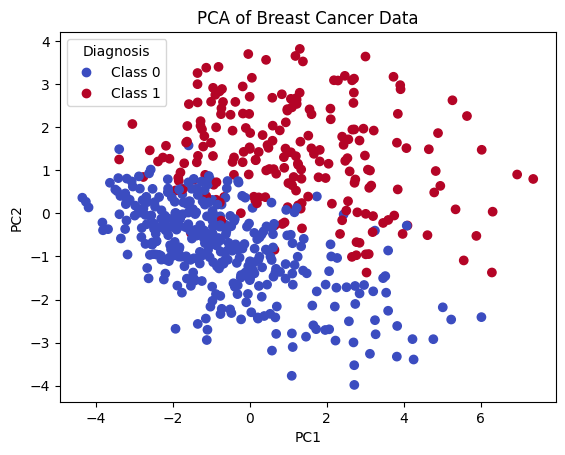

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df.drop('diagnosis', axis=1))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['diagnosis'], cmap='coolwarm')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Breast Cancer Data')
# Add legend for classes
handles, labels = scatter.legend_elements()
plt.legend(handles, ["Class 0", "Class 1"], title="Diagnosis")

plt.show()


#### Now X_pca is your new feature matrix with 2 columns (PC1, PC2).

In [44]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

In [45]:
# Train Classifier (Example: Logistic Regression)
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [46]:
# Evaluate Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9385964912280702

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114


Confusion Matrix:
 [[68  3]
 [ 4 39]]


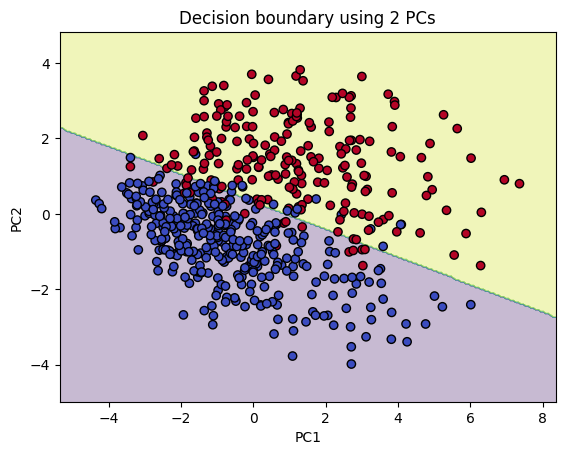

In [47]:
#  Visualize Decision Boundary (since 2 PCs are 2D)

# Create meshgrid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', cmap='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision boundary using 2 PCs")
plt.show()


In [48]:

# Columns used for training
features = ['radius_mean', 'texture_mean', 'smoothness_mean',
            'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean',
            'radius_se', 'texture_se', 'smoothness_se', 'compactness_se',
            'symmetry_se', 'fractal_dimension_se']

# Create sample patient data (2 rows, 12 features)
sample_data = pd.DataFrame([
    [14.5, 20.3, 0.10, 0.12, 0.18, 0.062, 0.30, 1.20, 0.007, 0.020, 0.16, 0.055],  # Patient A
    [18.2, 10.6, 0.09, 0.08, 0.16, 0.059, 0.25, 0.80, 0.006, 0.018, 0.14, 0.052]   # Patient B
], columns=features)

print("Sample data:")
print(sample_data)

# Scale with the same StandardScaler used during training
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(df.drop('diagnosis', axis=1))  # fit on training data
X_scaled_sample = scaler.transform(sample_data)                     # transform new samples

# Apply trained PCA
pca = PCA(n_components=2)
X_pca_full = pca.fit_transform(X_scaled_full)   # fit on training data
X_pca_sample = pca.transform(X_scaled_sample)   # transform new samples

print("\nPCA-transformed values for the 2 patients:")
print(X_pca_sample) # NOTE: visually you can see that both values are on bottom part. So they both should give same 0

y_pred = clf.predict(X_pca_sample)
print(y_pred)

Sample data:
   radius_mean  texture_mean  smoothness_mean  compactness_mean  \
0         14.5          20.3             0.10              0.12   
1         18.2          10.6             0.09              0.08   

   symmetry_mean  fractal_dimension_mean  radius_se  texture_se  \
0           0.18                   0.062       0.30         1.2   
1           0.16                   0.059       0.25         0.8   

   smoothness_se  compactness_se  symmetry_se  fractal_dimension_se  
0          0.007           0.020         0.16                 0.055  
1          0.006           0.018         0.14                 0.052  

PCA-transformed values for the 2 patients:
[[16.11921856 -9.48205705]
 [13.28121354 -8.33380767]]
[0 0]
